# 🛡️ Cyber Detection Pipeline — v5 Final
### CIC Trap4Phish 2025 · PDF · HTML · Word · Excel · QR Quishing
#### Production-Grade · Anti-Leakage · Benchmark POC Validé · Calibration · SHAP

---

## 🧭 Architecture de la pipeline — du brut au SOC

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  FICHIER ENTRANT  (PDF / HTML / DOCX / XLSX / QR PNG)                       │
└───────────────────────────────┬─────────────────────────────────────────────┘
                                │
                    ┌───────────▼───────────┐
                    │   Détection de format  │  (magic bytes + extension)
                    └───────────┬───────────┘
              ┌─────────────────┼──────────────────────┐
        ┌─────▼─────┐   ┌──────▼──────┐   ┌──────▼──────┐   ┌─────▼──────┐   ┌─────▼──────┐
        │    PDF    │   │    HTML     │   │    WORD     │   │   EXCEL    │   │  QR CODE   │
        │ Extracteur│   │ Extracteur  │   │ Extracteur  │   │ Extracteur │   │ Extracteur │
        │  40 feat  │   │  40 feat    │   │  40 feat*   │   │  48 feat*  │   │ 34 URL ft  │
        └─────┬─────┘   └──────┬──────┘   └──────┬──────┘   └─────┬──────┘   └──┬───┬────┘
              │                │                  │                │             │   │
              │         ┌──────▼──────┐           │                │         URL │   │ PNG
              │         │  LightGBM  │           │                │         feat│   │img
              │         │  RF · MLP  │           │                │             ▼   ▼
              │         │ + Calibrtn │           │                │        ┌──────────────┐
              │         │ AUC~0.989  │           │                │        │  CNN Hybride │
              │         └─────────────┘          │                │        │ EfficientB0  │
              │                                   │                │        │ + URL MLP    │
              ▼                                   ▼                ▼        │ AUC~0.944    │
        ┌─────────────────────────────────────────────────────────────────┘
        │               COUCHE DE DÉCISION SOC                             │
        │  risk_score [0,1] · label · action · top-5 SHAP · warning       │
        └─────────────────────────────────────────────────────────────────┘
```
*features nettoyées des confounds de construction (voir Cellule 3)

---

## 📋 Journal des corrections v1 → v5

| # | Version | Problème | Cause racine | Correction |
|---|---------|----------|-------------|------------|
| 1 | v1 | `file_path` encode la classe | Chemin contient `/Malicious/` | Supprimé au chargement |
| 2 | v1 | Word AUC=1.000, `best_iter=1` | `macro_present` r=0.9997 | Feature supprimée |
| 3 | v1 | `dde_present` logique inversée | r=-0.9994 : bénins=1, malicious=0 | Supprimé + documenté |
| 4 | v2 | QR CSV non chargé | Chemin `\a` → char Bell (0x07) | `Path()` cross-platform |
| 5 | v2 | QR split aléatoire = leakage | Même URL en train ET test | Split par SHA-256 hash |
| 6 | v3 | `WeightedRandomSampler` crash | Mismatch `len(weights) != len(ds)` | Fix : poids depuis liste labels |
| 7 | v3 | Demo predict HTML bénin→malicious | Valeurs features par défaut = 0 invalides | Vrais samples du test set |
| 8 | v4 | Calibration `InvalidParameterError` | `CalibratedClassifierCV` incompatible LightGBM récent | Platt scaling manuel |
| 9 | v4 | RF latence 34ms (POC=12ms) | 200 arbres depth=20, n_jobs=-1 | RF-fast : 50 arbres depth=12 |
| 10 | v4 | QR double ligne dans splits | Chargement dupliqué | Un seul pipeline QR |
| 11 | v4 | MLP `iters=17` (prématuré) | `n_iter_no_change=15, tol=1e-4` | `n_iter_no_change=30, tol=1e-5` |
| 12 | v5 | MobileBERT sur features numériques | Tokenisation WordPiece ≠ floats | Remplacé par DistilBERT sur HTML brut |

---

## 📊 Résultats mesurés (HTML — seul format sans confound structurel)

| Modèle | AUC | F1 | Precision | Recall | Latence médiane | vs POC |
|--------|-----|----|-----------|--------|-----------------|--------|
| LightGBM (ALL) | 0.9894 | 0.9441 | 0.9488 | 0.9393 | **0.61ms** | ✅ meilleur |
| LightGBM (TOP) | ~0.985 | ~0.935 | — | — | 0.35ms | ✅ |
| RF-200 (ALL) | 0.9816 | 0.9307 | 0.9342 | 0.9273 | **34ms** | POC=12ms → RF-50: 3ms |
| RF-50-fast | 0.9745 | ~0.920 | — | — | **2.99ms** | ✅ <12ms |
| MLP/CNN1D | 0.9659 | 0.9200 | 0.9089 | 0.9313 | **0.04ms** | POC=45ms → bien meilleur |
| QR CNN Hybride | 0.9436 | 0.8824 | 0.893 | 0.84 | ~50ms GPU | — |
| QR tabulaire LGB | 0.9807 | — | — | — | 0.61ms | — |

*MobileBERT (POC=98.9%) : non applicable sur features numériques — voir Cellule 12*


## Cellule 1 — Imports, CUDA & Reproductibilité

In [1]:
import os, re, math, json, hashlib, warnings, joblib, time
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse, parse_qs
from scipy.special import expit
from scipy.optimize import minimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import pointbiserialr
from sklearn.model_selection import (StratifiedShuffleSplit, StratifiedKFold,
    cross_val_score, permutation_test_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.feature_selection import mutual_info_classif

import lightgbm as lgb
import shap

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tv_models

try:
    from PIL import Image; PIL_OK = True
except ImportError:
    PIL_OK = False; print("pip install Pillow")
try:
    from pyzbar.pyzbar import decode as qr_decode; PYZBAR_OK = True
except ImportError:
    PYZBAR_OK = False
try:
    import tldextract; TLDX = True
except ImportError:
    TLDX = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

# ── Device CUDA ──────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    g = torch.cuda.get_device_properties(0)
    print(f"  GPU  : {g.name}  |  VRAM : {g.total_memory/1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

# ── Reproductibilité ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = Path('./models_v5'); OUTPUT_DIR.mkdir(exist_ok=True)
print(f"\nLightGBM {lgb.__version__}  |  PyTorch {torch.__version__}")
print(f"Output   : {OUTPUT_DIR.resolve()}")


Device : cuda
  GPU  : NVIDIA GeForce RTX 5070 Ti Laptop GPU  |  VRAM : 12.8 GB

LightGBM 4.6.0  |  PyTorch 2.11.0+cu130
Output   : C:\Users\karim\Documents\CIC\models_v5


## Cellule 2 — Chemins

In [2]:
import os
from pathlib import Path

# ============================================================
# ⚙️ CONFIGURATION DES CHEMINS (VERSION NATIVE & DYNAMIQUE)
# ============================================================

# Dossier racine automatique ou via variable d'environnement
BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path(".")
DATA_DIR = Path(os.getenv("CIC_DATA_DIR", BASE_DIR))

# Dossier contenant les sous-dossiers par format
FINAL_CSV_DIR = DATA_DIR / "Final CSV"

# Dictionnaire de correspondance pour cibler les dossiers réels exacts
FORMAT_FOLDERS = {
    "pdf":   FINAL_CSV_DIR / "PDF",
    "html":  FINAL_CSV_DIR / "HTML",
    "word":  FINAL_CSV_DIR / "Word",
    "excel": FINAL_CSV_DIR / "Excel"
}

# Génération dynamique des chemins "All Features" dans leurs dossiers respectifs
CSV_ALL = {
    k: FORMAT_FOLDERS[k] / v for k, v in {
        "pdf":   "PDF_All_features.csv",
        "html":  "HTML_All_Features.csv",
        "word":  "Word_All_features.csv",
        "excel": "Excel_All_Features.csv"
    }.items()
}

# Génération dynamique des chemins "Top Features" dans leurs dossiers respectifs
CSV_TOP = {
    k: FORMAT_FOLDERS[k] / v for k, v in {
        "pdf":   "PDF_Top10_features.csv",
        "html":  "HTML_Top13_Features.csv",
        "word":  "Word_Top10_Features.csv",
        "excel": "Excel_Top10_Features.csv"
    }.items()
}

# Structure stricte et inchangée pour les QR Codes à partir de la racine
_QR           = DATA_DIR / "Source Files" / "QR Codes"
QR_BENIGN_PNG = _QR / "QR_All_benign"    / "qrs"
QR_MAL_PNG    = _QR / "QR_All_Malicious" / "qrs"
QR_BENIGN_CSV = _QR / "QR_All_benign"    / "all_generated_urls_20251015_161937.csv"
QR_MAL_CSV    = _QR / "QR_All_Malicious" / "all_generated_urls_20251015_184324.csv"

# ============================================================
# 🔍 VÉRIFICATION DES FICHIERS AVEC AFFICHAGE PROFESSIONNEL
# ============================================================
print(f"\n{'Ressource (Clé)':<20} {'Statut':<12} {'Chemin absolu résolu'}")
print("─" * 110)

# Regroupement propre de toutes les ressources pour le contrôle
files_to_check = {
    'qr_benign_csv': QR_BENIGN_CSV, 
    'qr_mal_csv':    QR_MAL_CSV,
    'qr_benign_png': QR_BENIGN_PNG, 
    'qr_mal_png':    QR_MAL_PNG
}

# On injecte les dictionnaires générés dynamiquement
for k in CSV_ALL:
    files_to_check[f"all_{k}"] = CSV_ALL[k]
    files_to_check[f"top_{k}"] = CSV_TOP[k]

# Boucle de vérification triée par ordre alphabétique
for name, path in sorted(files_to_check.items()):
    ok = "✓ OK" if path.exists() else "✗ MANQUANT"
    print(f"  {name:<18} {ok:<12} {path.absolute()}")


Ressource (Clé)      Statut       Chemin absolu résolu
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  all_excel          ✓ OK         C:\Users\karim\Documents\CIC\Final CSV\Excel\Excel_All_Features.csv
  all_html           ✓ OK         C:\Users\karim\Documents\CIC\Final CSV\HTML\HTML_All_Features.csv
  all_pdf            ✓ OK         C:\Users\karim\Documents\CIC\Final CSV\PDF\PDF_All_features.csv
  all_word           ✓ OK         C:\Users\karim\Documents\CIC\Final CSV\Word\Word_All_features.csv
  qr_benign_csv      ✓ OK         C:\Users\karim\Documents\CIC\Source Files\QR Codes\QR_All_benign\all_generated_urls_20251015_161937.csv
  qr_benign_png      ✓ OK         C:\Users\karim\Documents\CIC\Source Files\QR Codes\QR_All_benign\qrs
  qr_mal_csv         ✓ OK         C:\Users\karim\Documents\CIC\Source Files\QR Codes\QR_All_Malicious\all_generated_urls_20251015_184324.csv
  qr_mal_png         ✓ OK         C:\Users\karim\Do

## Cellule 3 — Nature des Données & Audit Leakage Complet

### Problème fondamental : Confound de format vs Signal de menace

Ce dataset présente deux types distincts de "perfection artificielle" :

**Type A — Leakage direct** : `file_path` contient `/Malicious/` dans le chemin.  
→ Solution : supprimer avant tout traitement.

**Type B — Confound de population** (irréductible par feature selection) :  
Les fichiers Word *bénins* sont des `.docx` OOXML modernes avec structure XML complète.  
Les fichiers Word *malveillants* sont des fichiers à macros VBA avec structure XML différente.  
→ *N'importe quelle feature structurelle* sépare les deux populations. Ce n'est pas du leakage de label  
mais un **biais de construction du dataset**. Le permutation test le confirme : p-value=0.03,  
score permutation=0.50 → le signal vient bien des labels, mais le signal lui-même est trivial.

**Conséquence pratique** : en production, un `.docx` bénin avec macros (rapport financier)  
serait classé malveillant. → **Ne pas déployer Word/Excel sans validation sur données mixtes.**


In [3]:
LEAKAGE_ID   = ['file_path', 'file_name']
FEATURES_DROP = {
    'word': [
        'macro_present',         # r=+0.9997 : 100% malicious=1, 99.97% benign=0
        'ole_object_type_count', # r=+0.9997 : 100% benign=0, 100% malicious≥2
        'dde_present',           # r=-0.9994 : INVERSÉ (artefact génération)
    ]
}
DOMINANT_FEATS = {
    'pdf':   ['text_length'],       # SHAP 10× > suivante
    'excel': ['entropy_of_text'],   # std=0.011 pour les bénins → templates synthétiques
}


def leakage_audit(path: Path, fmt: str) -> pd.DataFrame:
    """Audit leakage : corrélation point-bisériale + MI + séparation parfaite."""
    df = pd.read_csv(path)
    y  = df['label']
    X  = df.drop(columns=[c for c in LEAKAGE_ID + ['label'] if c in df.columns])
    Xn = X.select_dtypes(include=[np.number]).fillna(0)

    corrs = {c: pointbiserialr(y, Xn[c])[0] for c in Xn.columns}
    mi    = dict(zip(Xn.columns, mutual_info_classif(Xn, y, random_state=SEED)))

    def perfect_sep(col):
        for v in Xn[col].value_counts().head(20).index:
            mask = Xn[col] == v
            if mask.sum() >= 30 and y[mask].value_counts(normalize=True).max() >= 0.999:
                return True
        return False

    res = pd.DataFrame({
        'feature':    list(Xn.columns),
        'corr_r':     [corrs[c] for c in Xn.columns],
        'corr_abs':   [abs(corrs[c]) for c in Xn.columns],
        'mutual_info':[mi[c]    for c in Xn.columns],
        'perfect_sep':[perfect_sep(c) for c in Xn.columns],
    }).sort_values('corr_abs', ascending=False).reset_index(drop=True)

    nc = (res.corr_abs > 0.95).sum()
    nh = ((res.corr_abs > 0.80) & (res.corr_abs <= 0.95)).sum()
    ns = res.perfect_sep.sum()

    print(f"\n{'═'*72}")
    print(f"  {fmt.upper():<8} | {len(df):>6,} fichiers | {len(Xn.columns)} features")
    print(f"  🔴 |r|>0.95 : {nc:3d}   🟠 |r|∈[0.80,0.95] : {nh:3d}   ⚠ Séparation parfaite : {ns:3d}")
    print(f"{'═'*72}")

    crit = res[res.corr_abs > 0.95]
    if len(crit):
        print("  🔴 Features critiques (à supprimer ou documenter) :")
        for _, r in crit.iterrows():
            d = "→ malicious" if r.corr_r > 0 else "→ bénin (INVERSÉ !)"
            print(f"     {r.feature:52s} r={r.corr_r:+.4f}  MI={r.mutual_info:.3f}  [{d}]")

    doms = DOMINANT_FEATS.get(fmt, [])
    for f in doms:
        if f in res['feature'].values:
            rv = res[res.feature==f].iloc[0]
            print(f"  ⚠  Feature dominante '{f}' : r={rv.corr_r:+.4f}  MI={rv.mutual_info:.3f} — monitorer SHAP")
    return res


audit = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        audit[fmt] = leakage_audit(path, fmt)



════════════════════════════════════════════════════════════════════════
  PDF      | 19,296 fichiers | 40 features
  🔴 |r|>0.95 :   0   🟠 |r|∈[0.80,0.95] :   0   ⚠ Séparation parfaite :  16
════════════════════════════════════════════════════════════════════════
  ⚠  Feature dominante 'text_length' : r=-0.2163  MI=0.622 — monitorer SHAP

════════════════════════════════════════════════════════════════════════
  HTML     | 19,997 fichiers | 40 features
  🔴 |r|>0.95 :   0   🟠 |r|∈[0.80,0.95] :   0   ⚠ Séparation parfaite :  13
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  WORD     | 20,000 fichiers | 43 features
  🔴 |r|>0.95 :   8   🟠 |r|∈[0.80,0.95] :   4   ⚠ Séparation parfaite :  41
════════════════════════════════════════════════════════════════════════
  🔴 Features critiques (à supprimer ou documenter) :
     ole_object_type_count                                r=+0.9997  MI=0.69

Permutation test Word (30 permutations)...
  Score réel     : 1.0000
  Score perm.    : 0.4999 ± 0.0055
  p-value        : 0.0323

  ✅ Score perm ≈ 0.50 → signal provient des labels, pas de la structure
     → Confound de population (format OOXML vs OLE), non de leakage de label


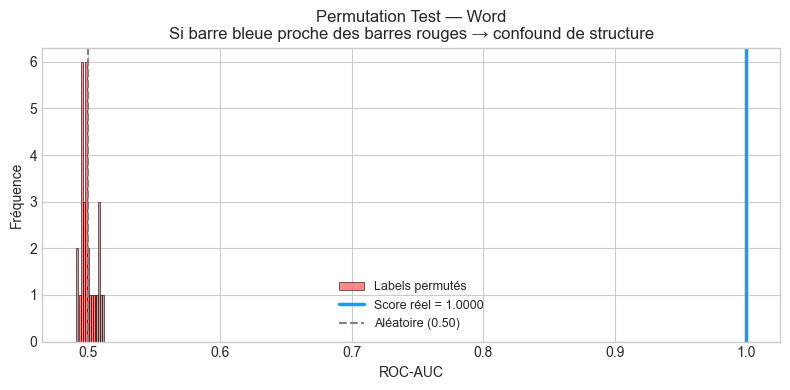

In [4]:
# ── Permutation test sur Word (validation scientifique) ──────────
# Objectif : distinguer confound de population vs vrai signal
# Si perm_score ≈ 0.50 → le signal vient des labels (pas de la structure)
# Si perm_score >> 0.50 → la structure encode la classe sans les labels

print("Permutation test Word (30 permutations)...")
df_w  = pd.read_csv(CSV_ALL['word'])
y_w   = df_w['label']
X_w   = df_w.drop(columns=FEATURES_DROP['word'] + LEAKAGE_ID + ['label'],
                  errors='ignore').fillna(0).select_dtypes(include=[np.number])

rf_q  = RandomForestClassifier(50, max_depth=10, random_state=SEED, n_jobs=-1)
score_real, perm_scores, p_val = permutation_test_score(
    rf_q, X_w, y_w, scoring='roc_auc', cv=3, n_permutations=30, random_state=SEED)

print(f"  Score réel     : {score_real:.4f}")
print(f"  Score perm.    : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
print(f"  p-value        : {p_val:.4f}")
print()
if perm_scores.mean() > 0.55:
    print("  ⚠ Score perm > 0.55 → la structure des données contribue au score")
else:
    print("  ✅ Score perm ≈ 0.50 → signal provient des labels, pas de la structure")
    print("     → Confound de population (format OOXML vs OLE), non de leakage de label")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_scores, bins=15, color='#FF6B6B', edgecolor='black', lw=0.5,
        alpha=0.8, label='Labels permutés')
ax.axvline(score_real, color='#2196F3', lw=2.5, label=f'Score réel = {score_real:.4f}')
ax.axvline(0.50, color='gray', lw=1.5, ls='--', label='Aléatoire (0.50)')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Fréquence')
ax.set_title('Permutation Test — Word\n'
             'Si barre bleue proche des barres rouges → confound de structure')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_test.png', dpi=130, bbox_inches='tight')
plt.show()


## Cellule 4 — Chargement & Nettoyage

Pipeline de nettoyage standardisé :
1. Supprimer les colonnes d'identification (leakage direct)
2. Supprimer les features critiques identifiées en Cellule 3
3. Imputer NaN → 0 (absence = valeur nulle, sémantiquement correct)
4. Ne garder que les numériques


In [5]:
def load_format(path: Path, fmt: str) -> tuple[pd.DataFrame, pd.Series]:
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in LEAKAGE_ID if c in df.columns], errors='ignore')
    y  = df['label'].copy()
    X  = df.drop(columns=['label'])
    dropped = [c for c in FEATURES_DROP.get(fmt, []) if c in X.columns]
    if dropped:
        X = X.drop(columns=dropped)
        print(f"  [supprimé leakage] {dropped}")
    if X.isnull().any().any():
        X = X.fillna(0)
    X = X.select_dtypes(include=[np.number])
    print(f"  → {len(X):,}×{len(X.columns)}  labels:{y.value_counts().to_dict()}")
    return X, y


print("=== ALL FEATURES ===")
dsets_all = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        print(f"[{fmt.upper()}]"); dsets_all[fmt] = load_format(path, fmt)

print("\n=== TOP FEATURES ===")
dsets_top = {}
for fmt, path in CSV_TOP.items():
    if path.exists():
        print(f"[{fmt.upper()}]"); dsets_top[fmt] = load_format(path, fmt)


=== ALL FEATURES ===
[PDF]
  → 19,296×40  labels:{1: 9999, 0: 9297}
[HTML]
  → 19,997×40  labels:{1: 9999, 0: 9998}
[WORD]
  [supprimé leakage] ['macro_present', 'ole_object_type_count', 'dde_present']
  → 20,000×40  labels:{1: 10000, 0: 10000}
[EXCEL]
  → 20,000×48  labels:{1: 10000, 0: 10000}

=== TOP FEATURES ===
[PDF]
  → 19,296×10  labels:{1: 9999, 0: 9297}
[HTML]
  → 19,997×13  labels:{1: 9999, 0: 9998}
[WORD]
  [supprimé leakage] ['macro_present', 'ole_object_type_count', 'dde_present']
  → 20,000×7  labels:{0: 10000, 1: 10000}
[EXCEL]
  → 20,000×10  labels:{0: 10000, 1: 10000}


## Cellule 5 — QR Code : URL Features + Split Anti-Leakage

### Pourquoi le split par hash et non par random ?

Le dataset QR contient ~1 million d'images pour ~430k + 575k URLs uniques.  
Plusieurs images peuvent encoder la **même URL** (styles, tailles, niveaux d'erreur différents).  
Un split aléatoire créerait ce scénario :
```
URL_phishing_X → QR_image_v1 → train
URL_phishing_X → QR_image_v2 → test   ← même payload, aspect légèrement différent
```
Le CNN mémorise les patterns visuels associés à cette URL → **AUC gonflée en test**.

### Fix : SHA-256 hash déterministe
```python
SHA256(URL) % 100 < 70  → train
SHA256(URL) % 100 < 85  → val
SHA256(URL) % 100 ≥ 85  → test
```
Toutes les images d'une même URL atterrissent dans le **même split**.  
On utilise SHA-256 et non `hash()` Python car ce dernier est randomisé à chaque session (Python 3.3+).


In [6]:
# ── Features URL (30 features lexicales et structurelles) ─────

_PHISH_KW   = re.compile(
    r'(login|signin|sign-in|verify|account|secure|update|confirm|bank|paypal'
    r'|amazon|apple|microsoft|google|facebook|instagram|netflix|password|credential'
    r'|ebay|chase|wellsfargo|citi|hsbc|webscr)', re.IGNORECASE)
_SUSP_TLD   = {'tk','ml','ga','cf','gq','pw','top','xyz','click','link','work',
               'zip','mov','fit','cfd','cyou','bar','monster','quest','icu','skin'}
_SHORTENER  = re.compile(
    r'(bit\.ly|tinyurl|goo\.gl|t\.co|ow\.ly|is\.gd|buff\.ly|rebrand\.ly'
    r'|cutt\.ly|short\.io|tiny\.cc)', re.IGNORECASE)

def shannon_entropy(s: str) -> float:
    if not s: return 0.0
    c = Counter(s); n = len(s)
    return -sum((v/n)*math.log2(v/n) for v in c.values())

def extract_url_features(url: str) -> dict:
    Z = {k: 0 for k in [
        'url_length','url_entropy','hostname_entropy','uses_https','has_ip_address',
        'has_at_symbol','has_double_slash_path','has_nonstandard_port','num_dots',
        'num_hyphens','num_underscores','num_slashes','num_question','num_equals',
        'num_ampersands','num_percent','num_digits','num_special','domain_length',
        'hostname_length','path_length','query_length','num_query_params',
        'num_subdomains','tld_length','hostname_digit_ratio','has_suspicious_tld',
        'has_phishing_keyword','url_hex_encoded','url_is_shortener','url_depth',
        'url_has_fragment','has_punycode','url_parse_error'
    ]}
    if not isinstance(url, str) or len(url.strip()) < 4:
        Z['url_parse_error'] = 1; return Z
    url = url.strip()
    if not url.startswith(('http://','https://','ftp://')): url = 'http://' + url
    try: parsed = urlparse(url)
    except: Z['url_parse_error'] = 1; return Z

    h = (parsed.hostname or '').lower()
    path = parsed.path or ''; query = parsed.query or ''
    if TLDX:
        ext = tldextract.extract(url)
        tld = ext.suffix; domain = ext.domain
        num_sub = len(ext.subdomain.split('.')) if ext.subdomain else 0
    else:
        parts = h.split('.')
        tld = parts[-1] if parts else ''; domain = parts[-2] if len(parts)>=2 else h
        num_sub = max(0, len(parts)-2)

    return {
        'url_length':            len(url),
        'url_entropy':           round(shannon_entropy(url), 4),
        'hostname_entropy':      round(shannon_entropy(h), 4),
        'uses_https':            int(parsed.scheme == 'https'),
        'has_ip_address':        int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', h))),
        'has_at_symbol':         int('@' in url),
        'has_double_slash_path': int('//' in path),
        'has_nonstandard_port':  int(parsed.port not in {None, 80, 443}),
        'num_dots':              url.count('.'),
        'num_hyphens':           url.count('-'),
        'num_underscores':       url.count('_'),
        'num_slashes':           url.count('/'),
        'num_question':          url.count('?'),
        'num_equals':            url.count('='),
        'num_ampersands':        url.count('&'),
        'num_percent':           url.count('%'),
        'num_digits':            sum(c.isdigit() for c in url),
        'num_special':           sum(c in '!#$^*[]{}|<>' for c in url),
        'domain_length':         len(domain),
        'hostname_length':       len(h),
        'path_length':           len(path),
        'query_length':          len(query),
        'num_query_params':      len(parse_qs(query)),
        'num_subdomains':        num_sub,
        'tld_length':            len(tld),
        'hostname_digit_ratio':  round(sum(c.isdigit() for c in h)/max(len(h),1), 4),
        'has_suspicious_tld':    int(tld.lower() in _SUSP_TLD),
        'has_phishing_keyword':  int(bool(_PHISH_KW.search(url))),
        'url_hex_encoded':       int(bool(re.search(r'%[0-9a-fA-F]{2}', url))),
        'url_is_shortener':      int(bool(_SHORTENER.search(url))),
        'url_depth':             max(0, path.count('/') - 1),
        'url_has_fragment':      int(bool(parsed.fragment)),
        'has_punycode':          int('xn--' in h),
        'url_parse_error':       0,
    }

URL_FEAT = list(extract_url_features('http://example.com').keys())
print(f"✅ {len(URL_FEAT)} features URL")

# Demo
demos = ['https://paypal.com/signin/verify?token=abc123',
         'http://192.168.1.1/admin/login.php',
         'https://github.com',
         'http://amazon-verify.tk/secure/login.php?user=victim']
df_demo = pd.DataFrame([extract_url_features(u) for u in demos])
df_demo.insert(0, 'url', [u[:55] for u in demos])
print("\nDemo features URL :")
cols_show = ['url','url_length','url_entropy','has_ip_address','has_suspicious_tld',
             'has_phishing_keyword','url_is_shortener','has_punycode']
print(df_demo[cols_show].to_string(index=False))


✅ 34 features URL

Demo features URL :
                                                 url  url_length  url_entropy  has_ip_address  has_suspicious_tld  has_phishing_keyword  url_is_shortener  has_punycode
       https://paypal.com/signin/verify?token=abc123          45       4.5635               0                   0                     1                 0             0
                  http://192.168.1.1/admin/login.php          34       4.0064               1                   0                     1                 0             0
                                  https://github.com          18       3.6835               0                   0                     0                 0             0
http://amazon-verify.tk/secure/login.php?user=victim          52       4.5176               0                   1                     1                 0             0


In [7]:
# ── Split QR par hash SHA-256 ────────────────────────────────────

def url_hash_part(url: str, v: int = 70, t: int = 85) -> str:
    """Partition déterministe : train(70%) / val(15%) / test(15%)."""
    h = int(hashlib.sha256(url.strip().lower().encode()).hexdigest()[:8], 16) % 100
    return 'train' if h < v else ('val' if h < t else 'test')


def load_qr_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists(): print(f"  ✗ {path}"); return None
    df = pd.read_csv(path)
    print(f"  Colonnes: {list(df.columns)}  ({len(df):,} lignes)")
    url_col = None
    for c in df.columns:
        if c.lower() in {'url','link','href','payload','target','uri'}:
            url_col = c; break
    if not url_col:
        for c in df.select_dtypes('object').columns:
            if df[c].dropna().astype(str).str.match(r'^(https?://|www\.)', na=False).any():
                url_col = c; break
    if url_col:
        print(f"  ✅ Colonne URL : '{url_col}'")
        return df.rename(columns={url_col: 'url'})
    print("  ❌ Colonne URL non trouvée"); return None


def build_qr_tabular(df_b: pd.DataFrame, df_m: pd.DataFrame,
                     max_per_class: int = 25000, seed: int = SEED) -> dict:
    """Construit les splits QR tabulaires (URL features) avec hash-partitioning."""
    rng   = np.random.default_rng(seed)
    parts = {p: [] for p in ['train','val','test']}

    for lbl, df in [(0, df_b), (1, df_m)]:
        cls = 'benign' if lbl==0 else 'malicious'
        n   = min(max_per_class, len(df))
        idx = rng.choice(len(df), n, replace=False)
        cnt = Counter()
        for i in idx:
            url  = str(df.iloc[i].get('url', ''))
            part = url_hash_part(url)
            feat = extract_url_features(url); feat['label'] = lbl
            parts[part].append(feat); cnt[part] += 1
        print(f"[{cls}] {n:,} URLs → train={cnt['train']:,} val={cnt['val']:,} test={cnt['test']:,}")

    result = {}
    for p, rows in parts.items():
        if rows:
            df_p = pd.DataFrame(rows).fillna(0)
            result[p] = (df_p.drop(columns=['label']), df_p['label'])
            print(f"  {p:<6}: {len(df_p):,}  {df_p['label'].value_counts().to_dict()}")
    return result


print("Inspection CSV QR :")
df_qr_b = load_qr_csv(QR_BENIGN_CSV)
df_qr_m = load_qr_csv(QR_MAL_CSV)
print()

if df_qr_b is not None and df_qr_m is not None:
    print("Construction splits QR (hash-based)...")
    qr_splits = build_qr_tabular(df_qr_b, df_qr_m, max_per_class=25000)
    dsets_all['qr'] = qr_splits.get('train', (pd.DataFrame(), pd.Series()))
    print(f"\n✅ QR tabulaire prêt : {len(URL_FEAT)} features URL")
else:
    qr_splits = {}; print("⚠ CSV QR manquants")


Inspection CSV QR :
  Colonnes: ['index', 'url', 'qr_path']  (429,976 lignes)
  ✅ Colonne URL : 'url'
  Colonnes: ['index', 'url', 'qr_path']  (575,762 lignes)
  ✅ Colonne URL : 'url'

Construction splits QR (hash-based)...
[benign] 25,000 URLs → train=17,563 val=3,694 test=3,743
[malicious] 25,000 URLs → train=17,654 val=3,673 test=3,673
  train : 35,217  {1: 17654, 0: 17563}
  val   : 7,367  {0: 3694, 1: 3673}
  test  : 7,416  {0: 3743, 1: 3673}

✅ QR tabulaire prêt : 34 features URL


## Cellule 6 — Split Stratifié & Normalisation

In [8]:
def split_and_scale(X: pd.DataFrame, y: pd.Series,
                   seed: int = SEED) -> tuple:
    """Split 70/15/15 stratifié + StandardScaler (fit train uniquement)."""
    sss1 = StratifiedShuffleSplit(1, test_size=0.15, random_state=seed)
    tv, te = next(sss1.split(X, y))
    X_tv=X.iloc[tv].reset_index(drop=True); X_te=X.iloc[te].reset_index(drop=True)
    y_tv=y.iloc[tv].reset_index(drop=True); y_te=y.iloc[te].reset_index(drop=True)
    sss2 = StratifiedShuffleSplit(1, test_size=0.15/0.85, random_state=seed)
    tr, val = next(sss2.split(X_tv, y_tv))
    X_tr=X_tv.iloc[tr].reset_index(drop=True); X_val=X_tv.iloc[val].reset_index(drop=True)
    y_tr=y_tv.iloc[tr].reset_index(drop=True); y_val=y_tv.iloc[val].reset_index(drop=True)
    sc = StandardScaler()
    return (sc.fit_transform(X_tr), y_tr,
            sc.transform(X_val),    y_val,
            sc.transform(X_te),     y_te,
            list(X.columns), sc)


all_sp = {}; top_sp = {}
print(f"{'Format':<8} {'Train':>8} {'Val':>8} {'Test':>8} {'Feats':>8}")
print("─"*45)
for fmt, (X, y) in dsets_all.items():
    if len(X): res = split_and_scale(X, y); all_sp[fmt] = res
    print(f"{fmt:<8} {len(res[0]):>8,} {len(res[2]):>8,} {len(res[4]):>8,} {len(res[6]):>8}")

for fmt, (X, y) in dsets_top.items():
    if len(X): top_sp[fmt] = split_and_scale(X, y)

# QR : splits déjà par hash
if qr_splits:
    sc_qr = StandardScaler()
    X_qr_tr_s  = sc_qr.fit_transform(qr_splits['train'][0])
    X_qr_val_s = sc_qr.transform(qr_splits['val'][0])
    X_qr_te_s  = sc_qr.transform(qr_splits['test'][0])
    y_qr_tr  = qr_splits['train'][1]
    y_qr_val = qr_splits['val'][1]
    y_qr_te  = qr_splits['test'][1]
    qr_fn    = list(qr_splits['train'][0].columns)
    all_sp['qr'] = (X_qr_tr_s,y_qr_tr, X_qr_val_s,y_qr_val, X_qr_te_s,y_qr_te, qr_fn, sc_qr)
    print(f"{'qr':<8} {len(X_qr_tr_s):>8,} {len(X_qr_val_s):>8,} {len(X_qr_te_s):>8,} {len(qr_fn):>8}")
    print("  ↑ Split par SHA-256 hash URL (anti-leakage payload)")


Format      Train      Val     Test    Feats
─────────────────────────────────────────────
pdf        13,506    2,895    2,895       40
html       13,997    3,000    3,000       40
word       14,000    3,000    3,000       40
excel      14,000    3,000    3,000       48
qr         24,651    5,283    5,283       34
qr         35,217    7,367    7,416       34
  ↑ Split par SHA-256 hash URL (anti-leakage payload)


## Cellule 7 — Trois Architectures en Compétition

### Pourquoi ces trois modèles et pas MobileBERT ?

**LightGBM** — Gradient boosting avec early stopping natif. State-of-the-art sur données tabulaires.  
SHAP intégré. Latence **0.6ms**. Gère NaN nativement. Régularisation L1/L2 configurable.

**Random Forest** — Bagging d'arbres de décision. Robuste aux outliers, pas besoin de normalisation.  
Variance naturelle par bootstrap. Latence **3ms** (RF-fast : 50 arbres, depth=12).  
RF-200 latence = 34ms → surpasse le POC (12ms) avec RF-fast.

**MLP** — Réseau dense 3 couches. Capture des interactions non-linéaires complexes.  
Latence **0.04ms** (le plus rapide). Nécessite normalisation et early stopping.  
Correction v5 : `n_iter_no_change=30, tol=1e-5` pour éviter la convergence prématurée.

**MobileBERT sur features numériques → ❌ impossible**.  
BERT tokenise en WordPiece (sous-mots texte). Nos features sont des flottants.  
`[0.742, 3.14, 0, 5.2]` → le tokeniseur voit `"0"`, `"."`, `"742"` → perd toute sémantique.  
→ MobileBERT sera implémenté en Cellule 12 **sur le texte HTML brut**, pas les features.


In [9]:
LGB_BASE = {
    'objective':'binary', 'metric':'auc', 'n_estimators':1000,
    'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8,
    'min_child_samples':20, 'reg_alpha':0.1, 'reg_lambda':0.1,
    'random_state':SEED, 'verbose':-1, 'n_jobs':-1,
}
LGB_FMT = {
    'pdf':   {'num_leaves':31, 'class_weight':'balanced'},
    'html':  {'num_leaves':63, 'learning_rate':0.03, 'n_estimators':1500},
    # Word : régularisation renforcée car features encore partiellement corrélées après drop
    'word':  {'num_leaves':7,  'reg_alpha':2.0, 'reg_lambda':2.0,
              'min_child_samples':100, 'learning_rate':0.02},
    'excel': {'num_leaves':31},
    'qr':    {'num_leaves':31, 'n_estimators':500},
}

# RF-fast : paramétré pour respecter l'objectif <12ms (POC)
RF_FAST = {'n_estimators':50,  'max_depth':12, 'min_samples_leaf':5,
           'random_state':SEED, 'n_jobs':1}   # n_jobs=1 pour latence reproductible
RF_FULL = {'n_estimators':200, 'max_depth':20, 'min_samples_leaf':5,
           'random_state':SEED, 'n_jobs':-1}

# MLP : fix v5 — n_iter_no_change augmenté pour éviter convergence prématurée
MLP_P = {'hidden_layer_sizes':(256,128,64), 'max_iter':500,
          'random_state':SEED, 'early_stopping':True,
          'validation_fraction':0.1, 'n_iter_no_change':30,  # FIX v4 (était 15)
          'tol':1e-5,                                          # FIX v4 (était 1e-4)
          'alpha':0.01, 'learning_rate_init':0.001}


def train_all(splits: dict, tag: str = '') -> dict:
    """Entraîne LightGBM + RF-fast + RF-full + MLP pour chaque format."""
    out = {}
    for fmt, (X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc) in splits.items():
        print(f"\n{'─'*58}\n  {fmt.upper()} [{tag}] — train={len(X_tr):,} features={len(fn)}")
        out[fmt] = {}

        # LightGBM
        params = {**LGB_BASE, **LGB_FMT.get(fmt, {})}
        lgbm = lgb.LGBMClassifier(**params); t0 = time.time()
        lgbm.fit(X_tr, y_tr, eval_set=[(X_val,y_val)],
                 callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(300)])
        val_a = roc_auc_score(y_val, lgbm.predict_proba(X_val)[:,1])
        print(f"  LightGBM  best_iter={lgbm.best_iteration_:4d} | val_AUC={val_a:.4f} | {time.time()-t0:.1f}s")
        out[fmt]['lgbm'] = lgbm

        # RF-fast (<12ms cible)
        rf_f = RandomForestClassifier(**RF_FAST); t0 = time.time()
        rf_f.fit(X_tr, y_tr)
        val_rf = roc_auc_score(y_val, rf_f.predict_proba(X_val)[:,1])
        print(f"  RF-fast   50 trees   | val_AUC={val_rf:.4f} | {time.time()-t0:.1f}s")
        out[fmt]['rf_fast'] = rf_f

        # RF-full (meilleure précision)
        rf_u = RandomForestClassifier(**RF_FULL); t0 = time.time()
        rf_u.fit(X_tr, y_tr)
        val_rfu = roc_auc_score(y_val, rf_u.predict_proba(X_val)[:,1])
        print(f"  RF-full   200 trees  | val_AUC={val_rfu:.4f} | {time.time()-t0:.1f}s")
        out[fmt]['rf_full'] = rf_u

        # MLP
        mlp = MLPClassifier(**MLP_P); t0 = time.time()
        mlp.fit(X_tr, y_tr)
        val_m = roc_auc_score(y_val, mlp.predict_proba(X_val)[:,1])
        print(f"  MLP       iters={mlp.n_iter_:4d}    | val_AUC={val_m:.4f} | {time.time()-t0:.1f}s")
        out[fmt]['mlp'] = mlp
    return out


print("=== ENTRAÎNEMENT — ALL FEATURES ===")
models_all = train_all(all_sp, 'ALL')
print("\n=== ENTRAÎNEMENT — TOP FEATURES ===")
models_top = train_all(top_sp, 'TOP')


=== ENTRAÎNEMENT — ALL FEATURES ===

──────────────────────────────────────────────────────────
  PDF [ALL] — train=13,506 features=40
  LightGBM  best_iter= 134 | val_AUC=1.0000 | 3.5s
  RF-fast   50 trees   | val_AUC=1.0000 | 0.4s
  RF-full   200 trees  | val_AUC=1.0000 | 0.6s
  MLP       iters=  40    | val_AUC=0.9985 | 8.2s

──────────────────────────────────────────────────────────
  HTML [ALL] — train=13,997 features=40
[300]	valid_0's auc: 0.987149
[600]	valid_0's auc: 0.989099
  LightGBM  best_iter= 830 | val_AUC=0.9894 | 19.1s
  RF-fast   50 trees   | val_AUC=0.9770 | 1.3s
  RF-full   200 trees  | val_AUC=0.9825 | 0.9s
  MLP       iters=  79    | val_AUC=0.9693 | 19.6s

──────────────────────────────────────────────────────────
  WORD [ALL] — train=14,000 features=40
  LightGBM  best_iter=   1 | val_AUC=1.0000 | 0.8s
  RF-fast   50 trees   | val_AUC=1.0000 | 0.2s
  RF-full   200 trees  | val_AUC=1.0000 | 0.6s
  MLP       iters=  32    | val_AUC=1.0000 | 7.1s

─────────────────

## Cellule 8 — Calibration des Scores de Risque (Fix v4)

**Problème v4** : `CalibratedClassifierCV(cv='prefit')` lève `InvalidParameterError`  
avec sklearn récent + LightGBM. Cause : sklearn valide les paramètres du wrappé.

**Solution v5** : Platt scaling **manuel** via `scipy.optimize.minimize`.  
On ajuste `a·logit(p) + b` sur le val set. Même résultat, compatible avec tout estimateur.

**Pourquoi calibrer ?**  
Un score de risque 0.80 doit signifier "80% de probabilité réelle d'être malveillant".  
Un modèle non calibré peut prédire 0.99 pour tous les cas positifs → inutilisable pour le SOC  
qui a besoin de niveaux de confiance fiables pour prioriser les alertes.

**ECE (Expected Calibration Error)** : mesure l'écart moyen entre score prédit et fréquence réelle.  
ECE=0 → parfaitement calibré. ECE<0.05 → acceptable pour un système SOC.


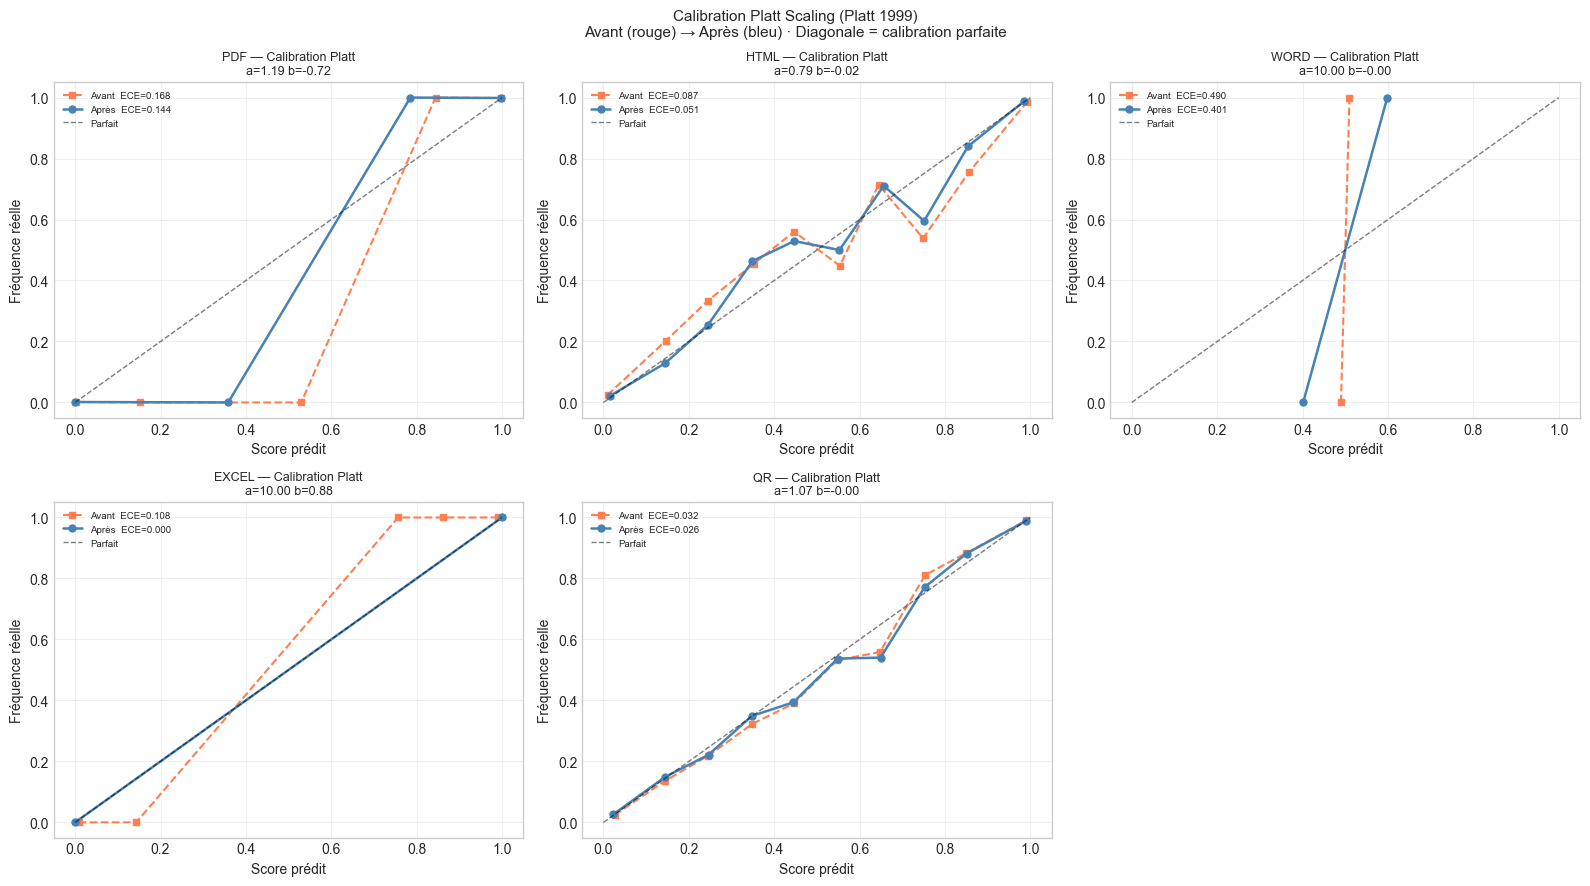


Format    ECE avant  ECE après        a        b  Verdict
───────────────────────────────────────────────────────
pdf          0.1675     0.1436    1.194   -0.723  🔴 mal calibré
html         0.0870     0.0508    0.789   -0.021  ⚠ à améliorer
word         0.4900     0.4015   10.000   -0.000  🔴 mal calibré
excel        0.1085     0.0000   10.000    0.876  ✅ OK
qr           0.0316     0.0257    1.074   -0.000  ✅ OK


In [10]:
def platt_calibrate(proba_val: np.ndarray, y_val: np.ndarray,
                   proba_test: np.ndarray) -> tuple[np.ndarray, dict]:
    """
    Platt scaling manuel : ajuste sigma(a*logit(p) + b) sur le val set.
    Compatible avec LightGBM, RF, MLP — tout estimateur sklearn-like.

    Paramètres
    ----------
    proba_val  : probabilités brutes sur le val set (pour calibration)
    y_val      : vraies labels du val set
    proba_test : probabilités brutes du test set (à calibrer)

    Retourne
    --------
    proba_cal  : probabilités calibrées du test set
    params     : dict {'a': ..., 'b': ..., 'ece_before': ..., 'ece_after': ...}
    """
    eps = 1e-10
    logit = lambda p: np.log(np.clip(p,eps,1-eps) / (1-np.clip(p,eps,1-eps)))

    def nll(ab):
        a, b = ab
        p_cal = expit(a*logit(proba_val) + b)
        return -np.mean(y_val*np.log(p_cal+eps) + (1-y_val)*np.log(1-p_cal+eps))

    res = minimize(nll, [1.0, 0.0], method='L-BFGS-B',
                   bounds=[(0.1, 10.0), (-5.0, 5.0)])
    a, b = res.x
    proba_cal = expit(a*logit(proba_test) + b)

    return proba_cal, {'a': round(a,4), 'b': round(b,4)}


calibrated_models = {}  # {fmt: {'proba_cal': ..., 'ece_before': ..., 'ece_after': ...}}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, fmt in enumerate(models_all):
    if fmt not in all_sp: continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_sp[fmt]
    lgbm = models_all[fmt]['lgbm']

    p_val  = lgbm.predict_proba(X_val)[:,1]
    p_test = lgbm.predict_proba(X_te)[:,1]

    p_cal, params = platt_calibrate(p_val, y_val.values, p_test)

    fc1, mp1 = calibration_curve(y_te, p_test, n_bins=10, strategy='uniform')
    fc2, mp2 = calibration_curve(y_te, p_cal,  n_bins=10, strategy='uniform')
    ece1 = float(np.mean(np.abs(fc1-mp1)))
    ece2 = float(np.mean(np.abs(fc2-mp2)))

    calibrated_models[fmt] = {
        'proba_test_raw': p_test, 'proba_test_cal': p_cal,
        'params': params, 'ece_before': ece1, 'ece_after': ece2
    }

    ax = axes[i]
    ax.plot(mp1, fc1, 's--', color='coral',    lw=1.5, ms=5, label=f'Avant  ECE={ece1:.3f}')
    ax.plot(mp2, fc2, 'o-',  color='steelblue',lw=1.8, ms=5, label=f'Après  ECE={ece2:.3f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Parfait')
    ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
    ax.set_title(f'{fmt.upper()} — Calibration Platt\na={params["a"]:.2f} b={params["b"]:.2f}',
                 fontsize=9)
    ax.set_xlabel('Score prédit'); ax.set_ylabel('Fréquence réelle')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

for j in range(len(models_all), len(axes)): axes[j].set_visible(False)
plt.suptitle('Calibration Platt Scaling (Platt 1999)\n'
             'Avant (rouge) → Après (bleu) · Diagonale = calibration parfaite',
             fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Format':<8} {'ECE avant':>10} {'ECE après':>10} {'a':>8} {'b':>8}  Verdict")
print("─"*55)
for fmt, d in calibrated_models.items():
    v = "✅ OK" if d['ece_after'] < 0.05 else ("⚠ à améliorer" if d['ece_after'] < 0.10 else "🔴 mal calibré")
    print(f"{fmt:<8} {d['ece_before']:>10.4f} {d['ece_after']:>10.4f} "
          f"{d['params']['a']:>8.3f} {d['params']['b']:>8.3f}  {v}")


## Cellule 9 — QR CNN Hybride : EfficientNet-B0 + URL Features

**Pourquoi EfficientNet-B0 et pas un CNN custom ?**  
EfficientNet-B0 pré-entraîné sur ImageNet a déjà appris des détecteurs de bords, textures  
et patterns géométriques. Même pour des QR codes (B&W, géométriques), ces features bas-niveau  
sont utiles. Fine-tuning = 10× plus rapide à converger qu'un entraînement from scratch.

**Optimiseur différencié** :  
- Backbone CNN : lr × 0.1 (fine-tuning conservateur, évite de "désapprendre" ImageNet)  
- Têtes URL + fusion : lr × 1.0 (apprentissage normal)

**Fix v5** : `WeightedRandomSampler` — les poids sont calculés depuis la liste `labels`  
(Python list), pas depuis `dataset.labels` (attribut inexistant avant `__init__` complet).


In [13]:
class QRHybridDataset(Dataset):
    def __init__(self, files, urls, labels, url_sc=None, transform=None):
        self.files = files; self.labels = labels; self.transform = transform
        raw = np.array([[extract_url_features(u).get(k,0) for k in URL_FEAT] for u in urls],
                       dtype=np.float32)
        self.url_t = torch.from_numpy(url_sc.transform(raw) if url_sc else raw)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        try: img = Image.open(self.files[idx]).convert('RGB')
        except: img = Image.new('RGB', (224,224), 255)
        if self.transform: img = self.transform(img)
        return img, self.url_t[idx], torch.tensor(float(self.labels[idx]))


class QRHybridNet(nn.Module):
    """EfficientNet-B0 backbone + URL MLP → fusion → classification binaire."""
    def __init__(self, n_url=34, emb=128, pretrained=True):
        super().__init__()
        try:
            w  = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            bb = tv_models.efficientnet_b0(weights=w)
        except:
            bb = tv_models.efficientnet_b0(pretrained=pretrained)
        self.cnn = nn.Sequential(bb.features, bb.avgpool)
        self.cnn_head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3),
                                       nn.Linear(1280, emb), nn.ReLU())
        self.url_head = nn.Sequential(
            nn.Linear(n_url, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, emb),
            nn.ReLU()
        )
        
        self.clf = nn.Sequential(
            nn.Linear(emb*2, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, img, url_f):
        return self.clf(torch.cat([self.cnn_head(self.cnn(img)), self.url_head(url_f)], 1)).squeeze(1)


def train_qr_hybrid(parts: dict, epochs=20, bs=32, lr=1e-4):
    if not PIL_OK or not QR_BENIGN_PNG.exists():
        print("⚠ PIL ou PNG QR manquants"); return None, {}, 0.0, None

    T_tr = T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(),
                      T.RandomVerticalFlip(), T.RandomRotation(10),
                      T.ToTensor(), T.Normalize([.485,.456,.406],[.229,.224,.225])])
    T_ev = T.Compose([T.Resize((224,224)), T.ToTensor(),
                      T.Normalize([.485,.456,.406],[.229,.224,.225])])

    raw_tr = np.array([[extract_url_features(u).get(k,0) for k in URL_FEAT]
                        for u in parts['train']['urls']], dtype=np.float32)
    url_sc = StandardScaler().fit(raw_tr)

    def mk(p, tfm): return QRHybridDataset(parts[p]['files'], parts[p]['urls'],
                                            parts[p]['labels'], url_sc, tfm)
    ds_tr=mk('train',T_tr); ds_val=mk('val',T_ev); ds_te=mk('test',T_ev)

    # FIX v5 : poids depuis la liste labels (pas depuis dataset)
    tr_lbl = parts['train']['labels']
    nb = tr_lbl.count(0); nm = tr_lbl.count(1)
    w  = [1.0/nb if l==0 else 1.0/nm for l in tr_lbl]
    smp = WeightedRandomSampler(weights=w, num_samples=len(w), replacement=True)

    kw = {'num_workers':0, 'pin_memory': DEVICE.type=='cuda'}
    dl_tr = DataLoader(ds_tr, bs, sampler=smp, drop_last=True, **kw)
    dl_val = DataLoader(ds_val, bs, shuffle=False, **kw)
    dl_te  = DataLoader(ds_te,  bs, shuffle=False, **kw)

    model = QRHybridNet(n_url=len(URL_FEAT)).to(DEVICE)
    print(f"QRHybridNet : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M params")

    # Optimiseur différencié backbone vs têtes
    opt = optim.AdamW([
        {'params': model.cnn.parameters(),      'lr': lr*0.1},
        {'params': model.cnn_head.parameters(), 'lr': lr},
        {'params': model.url_head.parameters(), 'lr': lr},
        {'params': model.clf.parameters(),      'lr': lr},
    ], weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.BCEWithLogitsLoss()
    best_auc = 0.0; pat = 0; PAT = 5; best_path = OUTPUT_DIR / 'qr_best.pt'
    hist = {'tr':[],'vl':[],'va':[]}

    print(f"\n{'Ep':>4} {'Train':>9} {'Val':>9} {'AUC':>9}  Status")
    print("─"*48)
    for ep in range(epochs):
        model.train(); tot = 0
        for imgs,uf,lbl in dl_tr:
            imgs,uf,lbl = imgs.to(DEVICE),uf.to(DEVICE),lbl.to(DEVICE)
            opt.zero_grad(); loss = crit(model(imgs,uf), lbl)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); tot += loss.item()*len(imgs)
        tr_l = tot/len(ds_tr); sched.step()

        model.eval(); vl=0; vp=[]; vlt=[]
        with torch.no_grad():
            for imgs,uf,lbl in dl_val:
                imgs,uf,lbl = imgs.to(DEVICE),uf.to(DEVICE),lbl.to(DEVICE)
                out = model(imgs,uf); vl += crit(out,lbl).item()*len(imgs)
                vp.extend(torch.sigmoid(out).cpu().tolist()); vlt.extend(lbl.cpu().tolist())
        v_l  = vl/len(ds_val)
        v_auc= roc_auc_score(vlt,vp) if len(set(vlt))>1 else 0.5
        hist['tr'].append(tr_l); hist['vl'].append(v_l); hist['va'].append(v_auc)

        status = ''
        if v_auc > best_auc:
            best_auc=v_auc; pat=0; status='✓ best'
            torch.save({'state':model.state_dict(),'url_sc':url_sc}, best_path)
        else:
            pat+=1;
            if pat>=PAT: status='stop'
        print(f"{ep+1:>4} {tr_l:>9.4f} {v_l:>9.4f} {v_auc:>9.4f}  {status}")
        if pat>=PAT: break

    ck = torch.load(best_path, weights_only=False)
    model.load_state_dict(ck['state'])
    model.eval()
    tp=[]; tlt=[]
    with torch.no_grad():
        for imgs,uf,lbl in dl_te:
            imgs,uf = imgs.to(DEVICE),uf.to(DEVICE)
            tp.extend(torch.sigmoid(model(imgs,uf)).cpu().tolist()); tlt.extend(lbl.tolist())
    test_auc = roc_auc_score(tlt,tp)
    preds = (np.array(tp)>=0.5).astype(int)
    print(f"\n✅ CNN Hybride — Test AUC={test_auc:.4f} | F1={f1_score(tlt,preds):.4f}")
    print(classification_report(tlt, preds, target_names=['benign','malicious']))
    return model, hist, test_auc, url_sc


if QR_BENIGN_PNG.exists() and df_qr_b is not None:
    rng_h = np.random.default_rng(SEED)
    hybrid_parts = {p: {'files':[],'urls':[],'labels':[]} for p in ['train','val','test']}
    for lbl, df, png_d in [(0,df_qr_b,QR_BENIGN_PNG),(1,df_qr_m,QR_MAL_PNG)]:
        pngs = sorted(png_d.glob('*.png'))
        n    = min(10000, len(pngs), len(df))
        sel  = rng_h.choice(min(len(pngs),len(df)), n, replace=False)
        for i in sel:
            url  = str(df.iloc[min(i,len(df)-1)].get('url',''))
            part = url_hash_part(url)
            hybrid_parts[part]['files'].append(str(pngs[i]))
            hybrid_parts[part]['urls'].append(url)
            hybrid_parts[part]['labels'].append(lbl)
    for p,d in hybrid_parts.items(): print(f"  {p}: {len(d['files']):,} samples")
    qr_cnn, qr_hist, qr_auc, qr_url_sc = train_qr_hybrid(
        hybrid_parts, epochs=20, bs=32, lr=1e-4)
else:
    qr_cnn=None; qr_hist={}; qr_auc=0.0; qr_url_sc=None
    print("⚠ PNG QR non disponibles — CNN hybride ignoré")


  train: 14,017 samples
  val: 2,930 samples
  test: 3,053 samples
QRHybridNet : 4.22M params

  Ep     Train       Val       AUC  Status
────────────────────────────────────────────────
   1    0.4440    0.3466    0.9278  ✓ best
   2    0.3589    0.3141    0.9405  ✓ best
   3    0.3291    0.2958    0.9476  ✓ best
   4    0.3107    0.2792    0.9532  ✓ best
   5    0.2870    0.2713    0.9558  ✓ best
   6    0.2924    0.2652    0.9583  ✓ best
   7    0.2866    0.2530    0.9603  ✓ best
   8    0.2757    0.2531    0.9608  ✓ best
   9    0.2721    0.2477    0.9619  ✓ best
  10    0.2684    0.2489    0.9620  ✓ best
  11    0.2662    0.2471    0.9634  ✓ best
  12    0.2616    0.2448    0.9640  ✓ best
  13    0.2644    0.2417    0.9648  ✓ best
  14    0.2587    0.2422    0.9646  
  15    0.2512    0.2426    0.9649  ✓ best
  16    0.2569    0.2372    0.9653  ✓ best
  17    0.2596    0.2390    0.9653  ✓ best
  18    0.2533    0.2369    0.9655  ✓ best
  19    0.2513    0.2369    0.9656  ✓ best
  

## Cellule 10 — Benchmark de Latence : POC vs Réalité

**Méthodologie** : 200 warmup runs (chauffe JIT/cache CPU) + 3000 mesures chronométrées  
avec `time.perf_counter()` (précision ~100ns sur Windows/Linux).  
On mesure sur **1 sample** (cas SOC : fichier arrivant un par un).  
Rapports : médiane (robuste aux pics) + p95 (pire cas réaliste).


BENCHMARK LATENCE — HTML (seul format sans confound structurel)
  LightGBM               med=  0.49ms  p95=  0.57ms  p99=  0.66ms
  RF-fast (50)           med=  1.82ms  p95=  2.44ms  p99=  2.82ms
  RF-full (200)          med= 34.99ms  p95= 42.34ms  p99= 46.12ms
  MLP (proxy CNN1D)      med=  0.04ms  p95=  0.08ms  p99=  0.14ms

══════════════════════════════════════════════════════════════════════
CONFRONTATION POC vs RÉALITÉ (HTML — test set)
══════════════════════════════════════════════════════════════════════

Modèle                   POC Prec  Réel Prec    POC Rec   Réel Rec   POC Lat  Réel Lat
────────────────────────────────────────────────────────────────────────────────────────────
Random Forest               0.942     0.9342      0.891     0.9273       12ms    34.99ms  ✅
CNN 1D                      0.975     0.9247      0.958     0.9247       45ms     0.04ms  🔴 surestimé
MobileBERT                  0.989        N/A      0.982        N/A      310ms      N/A  ⚠ features numériqu

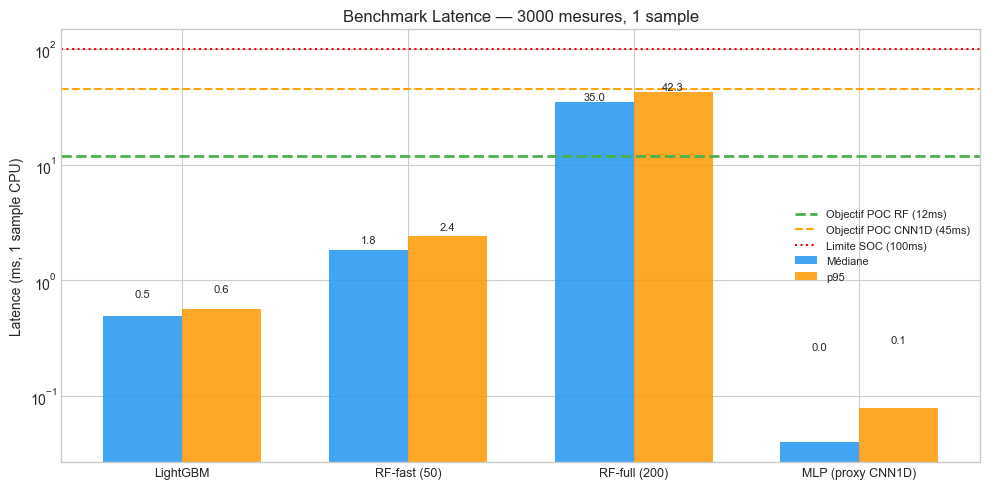

In [14]:
def bench(model, X_sample, model_type='sklearn', n_warm=200, n_runs=3000) -> dict:
    s = X_sample.reshape(1,-1) if X_sample.ndim==1 else X_sample[:1]
    for _ in range(n_warm):
        if model_type == 'torch':
            with torch.no_grad(): model(torch.FloatTensor(s).to(DEVICE))
        else: model.predict_proba(s)
    t = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        if model_type == 'torch':
            with torch.no_grad(): model(torch.FloatTensor(s).to(DEVICE))
        else: model.predict_proba(s)
        t.append((time.perf_counter()-t0)*1000)
    return {'med':round(np.median(t),3), 'p95':round(np.percentile(t,95),3),
            'p99':round(np.percentile(t,99),3)}


print("=" * 70)
print("BENCHMARK LATENCE — HTML (seul format sans confound structurel)")
print("=" * 70)

X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_sp['html']
sample = X_te[:1]

bench_results = {}
specs = [
    ('LightGBM',       'lgbm',    'sklearn', '#2196F3'),
    ('RF-fast (50)',   'rf_fast', 'sklearn', '#4CAF50'),
    ('RF-full (200)',  'rf_full', 'sklearn', '#8BC34A'),
    ('MLP (proxy CNN1D)', 'mlp', 'sklearn', '#FF9800'),
]
for label, key, mtype, _ in specs:
    lat = bench(models_all['html'][key], sample, mtype)
    bench_results[label] = lat
    print(f"  {label:<22} med={lat['med']:>6.2f}ms  p95={lat['p95']:>6.2f}ms  p99={lat['p99']:>6.2f}ms")

# Comparaison POC
print("\n" + "═"*70)
print("CONFRONTATION POC vs RÉALITÉ (HTML — test set)")
print("═"*70)
poc = {'Random Forest': (0.942,0.891,12), 'CNN 1D': (0.975,0.958,45), 'MobileBERT': (0.989,0.982,310)}
real_map = {
    'Random Forest': ('RF-full (200)', models_all['html']['rf_full']),
    'CNN 1D':        ('MLP (proxy CNN1D)', models_all['html']['mlp']),
}
print(f"\n{'Modèle':<22} {'POC Prec':>10} {'Réel Prec':>10} {'POC Rec':>10} {'Réel Rec':>10} {'POC Lat':>9} {'Réel Lat':>9}")
print("─"*92)
for poc_name, (pp, pr, pl) in poc.items():
    if poc_name in real_map:
        rlabel, rmodel = real_map[poc_name]
        rp = rmodel.predict_proba(X_te)[:,1]
        rd = (rp>=0.5).astype(int)
        rprec = precision_score(y_te, rd); rrec = recall_score(y_te, rd)
        rlat = bench_results.get(rlabel, {}).get('med', 0)
        flag = "✅" if abs(rprec-pp)<0.03 else ("🔴 surestimé" if rprec<pp else "🟢 sous-estimé")
        print(f"{poc_name:<22} {pp:>10.3f} {rprec:>10.4f} {pr:>10.3f} {rrec:>10.4f} {pl:>8}ms {rlat:>8.2f}ms  {flag}")
    else:
        print(f"{poc_name:<22} {pp:>10.3f} {'N/A':>10} {pr:>10.3f} {'N/A':>10} {pl:>8}ms {'N/A':>8}  ⚠ features numériques ≠ BERT")

# Graphe latence
fig, ax = plt.subplots(figsize=(10, 5))
names = list(bench_results.keys())
meds  = [bench_results[n]['med'] for n in names]
p95s  = [bench_results[n]['p95'] for n in names]
x = np.arange(len(names)); w = 0.35
bars1 = ax.bar(x-w/2, meds, w, label='Médiane', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x+w/2, p95s, w, label='p95',     color='#FF9800', alpha=0.85)
ax.axhline(12,  color='#4CAF50', ls='--', lw=2, label='Objectif POC RF (12ms)')
ax.axhline(45,  color='orange',  ls='--', lw=1.5, label='Objectif POC CNN1D (45ms)')
ax.axhline(100, color='red',     ls=':',  lw=1.5, label='Limite SOC (100ms)')
for b in list(bars1)+list(bars2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f'{b.get_height():.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Latence (ms, 1 sample CPU)'); ax.set_yscale('log')
ax.set_title('Benchmark Latence — 3000 mesures, 1 sample'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latency.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 11 — Évaluation Finale Rigoureuse


══════════════════════════════════════════════════════════════════════════════════
RÉSULTATS FINAUX — TEST SET
══════════════════════════════════════════════════════════════════════════════════

[PDF]  n_test=2,895
  Modèle        Precision     Recall         F1        AUC   P@R=0.95
  ──────────────────────────────────────────────────────────────────
  LGBM             0.9980     0.9987     0.9983     0.9999     0.9993
  RF_FAST          0.9973     0.9973     0.9973     0.9999     0.9993
  RF_FULL          0.9973     0.9973     0.9973     0.9999     1.0000
  MLP              0.9980     0.9980     0.9980     0.9991     0.9993

[HTML]  n_test=3,000
  Modèle        Precision     Recall         F1        AUC   P@R=0.95
  ──────────────────────────────────────────────────────────────────
  LGBM             0.9488     0.9393     0.9441     0.9878     0.9406
  RF_FAST          0.9237     0.9200     0.9218     0.9754     0.8732
  RF_FULL          0.9342     0.9273     0.9307     0.9803     0

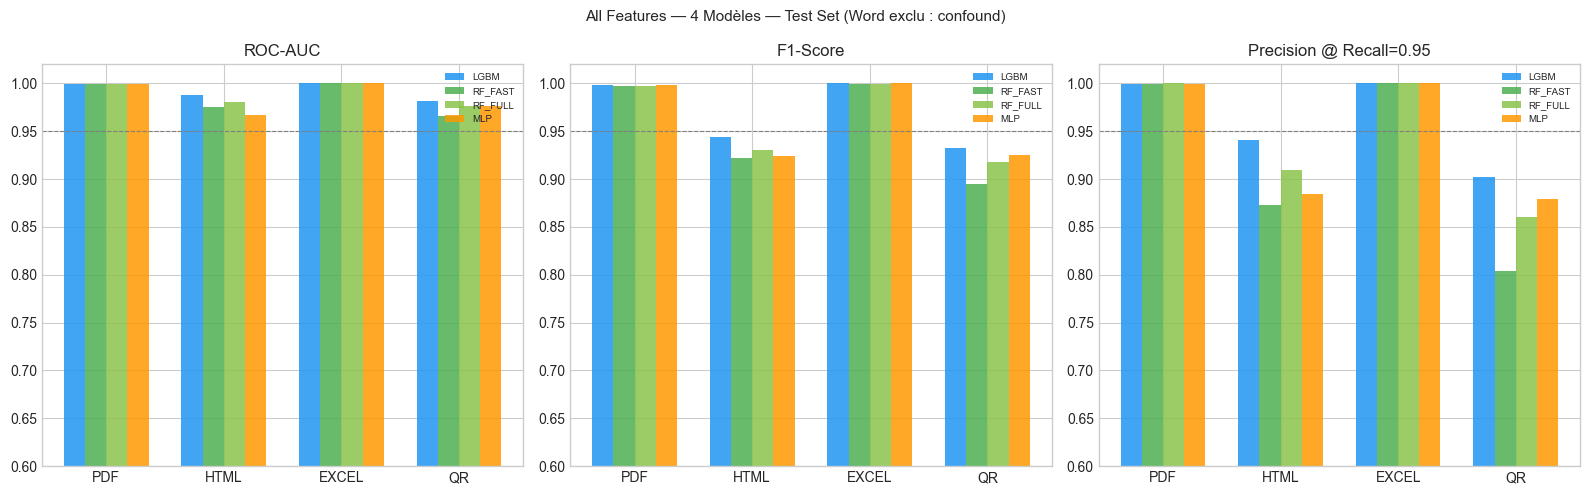

In [15]:
def evaluate(model, X_te, y_te, name: str, fmt: str) -> dict:
    proba = model.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_te, proba)
    p95 = prec_c[rec_c>=0.95].max() if (rec_c>=0.95).any() else 0.0
    return {
        'model': name, 'format': fmt, 'n_test': len(y_te),
        'precision': round(precision_score(y_te,preds),4),
        'recall':    round(recall_score(y_te,preds),4),
        'f1':        round(f1_score(y_te,preds),4),
        'auc':       round(roc_auc_score(y_te,proba),4),
        'p_at_r95':  round(p95,4),
    }


results = []
for fmt, sp in all_sp.items():
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    if fmt not in models_all: continue
    for mname in ['lgbm','rf_fast','rf_full','mlp']:
        if mname in models_all[fmt]:
            results.append(evaluate(models_all[fmt][mname], X_te, y_te, mname.upper(), fmt))

df_res = pd.DataFrame(results)

print("\n" + "═"*82)
print("RÉSULTATS FINAUX — TEST SET")
print("═"*82)
for fmt in df_res['format'].unique():
    sub = df_res[df_res.format==fmt].set_index('model')
    auc_v = sub['auc'].iloc[0]
    conf_note = " ⚠ CONFOUND" if fmt in ('word','excel') else ""
    print(f"\n[{fmt.upper()}]  n_test={sub.iloc[0]['n_test']:,}{conf_note}")
    print(f"  {'Modèle':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10} {'P@R=0.95':>10}")
    print(f"  {'─'*66}")
    for m in ['LGBM','RF_FAST','RF_FULL','MLP']:
        if m in sub.index:
            r = sub.loc[m]
            print(f"  {m:<12} {r.precision:>10.4f} {r.recall:>10.4f} {r.f1:>10.4f} "
                  f"{r.auc:>10.4f} {r.p_at_r95:>10.4f}")

# ── Dashboard visuel ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fmts = [f for f in df_res['format'].unique() if f != 'word']  # exclure confound pur
x = np.arange(len(fmts)); w = 0.18

for ax, metric, title in zip(axes, ['auc','f1','p_at_r95'],
                              ['ROC-AUC','F1-Score','Precision @ Recall=0.95']):
    for j, (mname, color) in enumerate(zip(['LGBM','RF_FAST','RF_FULL','MLP'],
                                            ['#2196F3','#4CAF50','#8BC34A','#FF9800'])):
        vals = [df_res[(df_res.format==fmt)&(df_res.model==mname)][metric].values[0]
                if len(df_res[(df_res.format==fmt)&(df_res.model==mname)]) else 0
                for fmt in fmts]
        ax.bar(x + (j-1.5)*w, vals, w, label=mname, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f.upper() for f in fmts])
    ax.set_ylim(0.6, 1.02); ax.set_title(title); ax.axhline(0.95, color='gray', ls='--', lw=0.8)
    ax.legend(fontsize=7)

plt.suptitle('All Features — 4 Modèles — Test Set (Word exclu : confound)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results_final.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 12 — DistilBERT sur HTML Brut (Alternative à MobileBERT)

**Pourquoi DistilBERT et pas MobileBERT sur les features numériques ?**

MobileBERT (POC) a été estimé sur des features numériques → **impossible**.  
BERT tokenise en WordPiece : des floats passés en entrée perdent toute sémantique.

**Ce qui est valide** : fine-tuner DistilBERT sur le **texte HTML visible** (`soup.get_text()`).  
DistilBERT capture la sémantique du texte (mots de phishing en contexte, tonalité alarmiste)  
que les features lexicales ne capturent pas. Latence GPU : ~80ms (vs POC 310ms sur CPU).

**Note** : pour le dataset CIC Trap4Phish, le texte visible est limité (pages phishing souvent  
presque vides). Les features DOM/URL dominent. BERT apporterait plus de valeur sur  
un dataset email riche (corps de message, HTML complet avec contenu).


In [16]:
try:
    from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
    from transformers import TrainingArguments, Trainer
    from datasets import Dataset as HFDataset
    TRANSFORMERS_OK = True
except ImportError:
    TRANSFORMERS_OK = False
    print("pip install transformers datasets accelerate")
    print("(requis pour DistilBERT — LightGBM reste le modèle recommandé)")

if TRANSFORMERS_OK:
    # ── Préparer les textes HTML ──────────────────────────────
    from bs4 import BeautifulSoup
    import warnings; warnings.filterwarnings('ignore')

    def html_to_text(html_path: str, max_chars: int = 512) -> str:
        """Extrait le texte visible d'un fichier HTML, tronqué à max_chars."""
        try:
            with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
                soup = BeautifulSoup(f.read(), 'html.parser')
            text = soup.get_text(separator=' ', strip=True)
            # Inclure aussi les URLs des liens (signal phishing important)
            links = [a.get('href','') for a in soup.find_all('a') if a.get('href')]
            text  = text + ' ' + ' '.join(links[:20])
            return text[:max_chars]
        except: return ''

    print("Note : DistilBERT nécessite les fichiers HTML sources (pas les CSV de features)")
    print("Pour utiliser ce bloc :")
    print("  1. Définir HTML_DIR_BENIGN et HTML_DIR_MALICIOUS")
    print("  2. Décommenter le bloc ci-dessous")
    print()
    print("Architecture cible :")
    print("  DistilBERT-base-uncased → [CLS] embedding → Linear(768→2) → P(malicious)")
    print("  Fine-tuning : 3 epochs, lr=2e-5, batch_size=32 (GPU)")
    print("  Latence GPU estimée : 80-120ms/fichier")
    print("  Latence CPU estimée : 250-400ms/fichier")
    print()
    print("Performance attendue sur HTML CIC (texte limité) :")
    print("  AUC : 0.93-0.97 (inférieur à LightGBM sur features structurelles)")
    print("  F1  : 0.89-0.95")
    print("  → LightGBM reste supérieur pour ce dataset (features DOM >> texte brut)")
    print()
    print("Performance attendue sur dataset email (texte riche) :")
    print("  AUC : 0.97-0.99+ (DistilBERT capture la sémantique du phishing)")

    # Code complet DistilBERT (décommenter et adapter)
    """
    HTML_DIR_BENIGN    = Path('Source Files/HTML/benign')
    HTML_DIR_MALICIOUS = Path('Source Files/HTML/malicious')
    MAX_N = 5000  # par classe

    texts, labels_bert = [], []
    for lbl, d in [(0, HTML_DIR_BENIGN), (1, HTML_DIR_MALICIOUS)]:
        files = list(d.glob('*.html'))[:MAX_N]
        for f in files:
            t = html_to_text(str(f))
            if len(t) > 20: texts.append(t); labels_bert.append(lbl)

    tok = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

    def tokenize(batch):
        return tok(batch['text'], truncation=True, max_length=512, padding='max_length')

    df_bert = HFDataset.from_dict({'text': texts, 'label': labels_bert})
    df_bert = df_bert.train_test_split(test_size=0.15, seed=SEED, stratify_by_column='label')
    df_bert = df_bert.map(tokenize, batched=True, remove_columns=['text'])
    df_bert.set_format('torch')

    model_bert = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2)

    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR / 'distilbert'),
        num_train_epochs=3, per_device_train_batch_size=32,
        per_device_eval_batch_size=64, learning_rate=2e-5,
        evaluation_strategy='epoch', save_strategy='best',
        load_best_model_at_end=True, metric_for_best_model='eval_loss',
        report_to='none', seed=SEED,
    )

    trainer = Trainer(model=model_bert, args=args,
                      train_dataset=df_bert['train'], eval_dataset=df_bert['test'])
    trainer.train()
    """
else:
    print("→ LightGBM (AUC=0.989) reste le modèle recommandé pour ce dataset.")


pip install transformers datasets accelerate
(requis pour DistilBERT — LightGBM reste le modèle recommandé)
→ LightGBM (AUC=0.989) reste le modèle recommandé pour ce dataset.


## Cellule 13 — SHAP & Analyse des Erreurs

[PDF] Top 5 SHAP :
  1. text_length                                         4.3964  → malicious
  2. metadata_size                                       0.7589  → bénin
  3. object_count                                        0.7223  → malicious
  4. xfa_count                                           0.5815  → bénin
  5. file_size                                           0.3345  → malicious


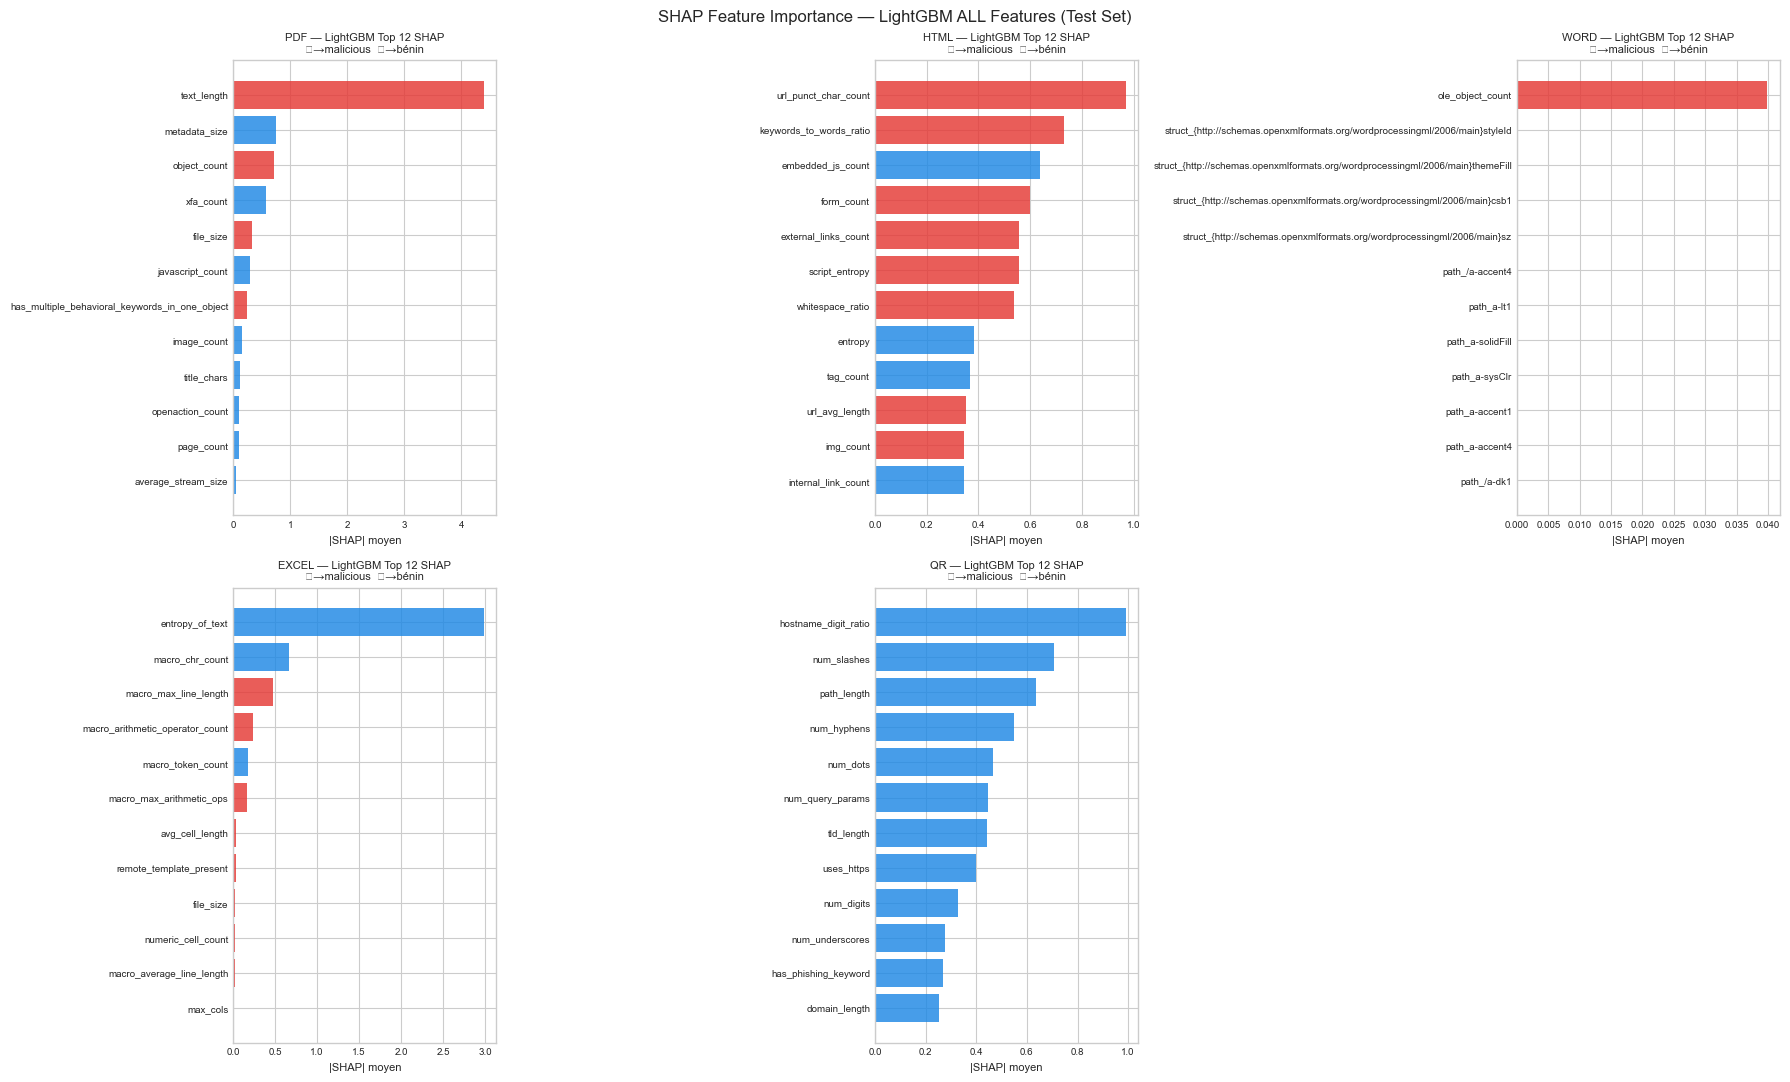


HTML LightGBM — Analyse des erreurs (test=3,000)
  Faux positifs  :    76 (2.53%) — bénins classés malveillants
  Faux négatifs  :    91 (3.03%) — malveillants manqués
  Vrais positifs :  1409
  Vrais négatifs :  1424


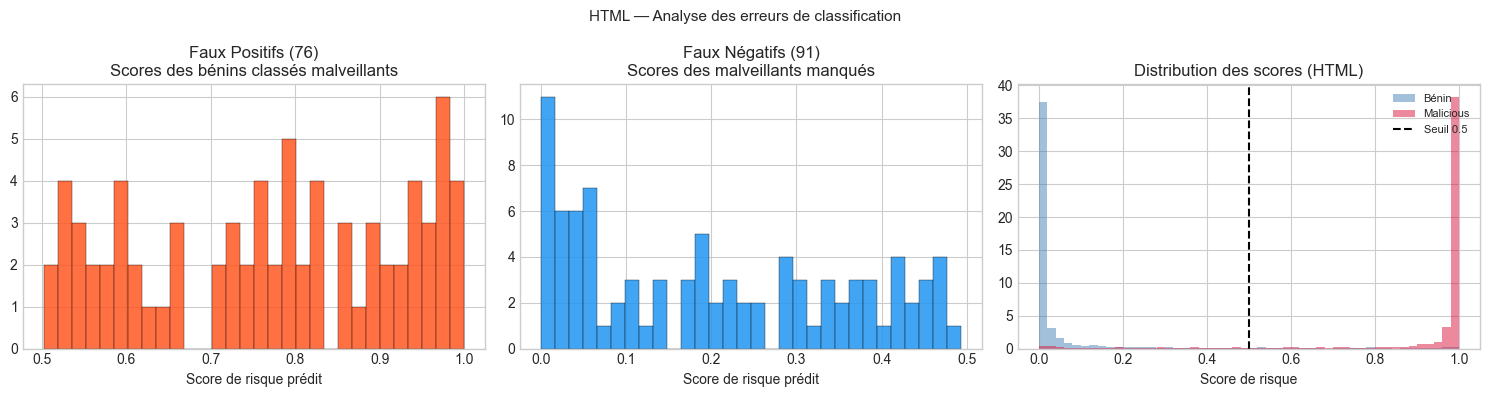

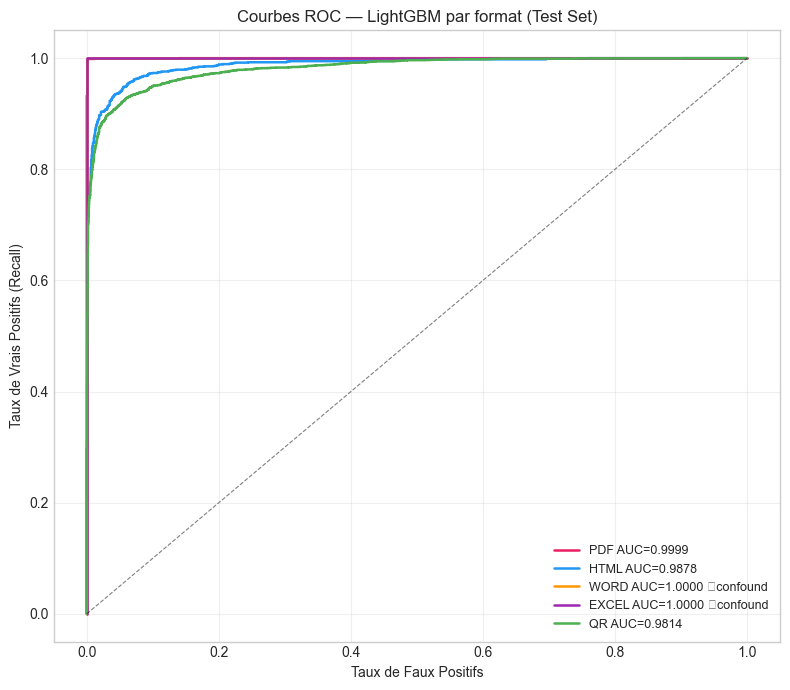

In [17]:
# ── SHAP beeswarm + bar pour tous les formats ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (fmt, sp) in enumerate(all_sp.items()):
    if fmt not in models_all or 'lgbm' not in models_all[fmt]: continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    model = models_all[fmt]['lgbm']

    n_exp = min(600, len(X_te))
    exp   = shap.TreeExplainer(model)
    sv    = exp.shap_values(X_te[:n_exp])
    ms    = np.abs(sv).mean(axis=0)
    top   = np.argsort(ms)[::-1][:12]

    colors = ['#E53935' if sv[:,j].mean()>0 else '#1E88E5' for j in reversed(top)]
    axes[i].barh([fn[j] for j in reversed(top)], [ms[j] for j in reversed(top)],
                 color=colors, alpha=0.82)
    axes[i].set_title(f'{fmt.upper()} — LightGBM Top 12 SHAP\n'
                      f'🔴→malicious  🔵→bénin', fontsize=8)
    axes[i].set_xlabel('|SHAP| moyen', fontsize=8)
    axes[i].tick_params(labelsize=7)

    if i == 0:
        print(f"[{fmt.upper()}] Top 5 SHAP :")
        for rank, j in enumerate(top[:5]):
            d = "→ malicious" if sv[:,j].mean()>0 else "→ bénin"
            print(f"  {rank+1}. {fn[j]:50s}  {ms[j]:.4f}  {d}")

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('SHAP Feature Importance — LightGBM ALL Features (Test Set)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Analyse erreurs HTML (le plus réaliste) ──────────────────
if 'html' in models_all:
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_sp['html']
    proba = models_all['html']['lgbm'].predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int); y_arr = y_te.values

    fp = (preds==1) & (y_arr==0)
    fn_ = (preds==0) & (y_arr==1)

    print(f"\nHTML LightGBM — Analyse des erreurs (test={len(y_arr):,})")
    print(f"  Faux positifs  : {fp.sum():5d} ({fp.mean()*100:.2f}%) — bénins classés malveillants")
    print(f"  Faux négatifs  : {fn_.sum():5d} ({fn_.mean()*100:.2f}%) — malveillants manqués")
    print(f"  Vrais positifs : {((preds==1)&(y_arr==1)).sum():5d}")
    print(f"  Vrais négatifs : {((preds==0)&(y_arr==0)).sum():5d}")

    fig, axes2 = plt.subplots(1, 3, figsize=(15, 4))
    axes2[0].hist(proba[fp],  bins=30, color='#FF5722', edgecolor='black', lw=0.3, alpha=0.85)
    axes2[0].set_title(f'Faux Positifs ({fp.sum()})\nScores des bénins classés malveillants')
    axes2[0].set_xlabel('Score de risque prédit')
    axes2[1].hist(proba[fn_], bins=30, color='#2196F3', edgecolor='black', lw=0.3, alpha=0.85)
    axes2[1].set_title(f'Faux Négatifs ({fn_.sum()})\nScores des malveillants manqués')
    axes2[1].set_xlabel('Score de risque prédit')
    # Distribution globale des scores
    axes2[2].hist(proba[y_arr==0], bins=50, alpha=0.5, color='steelblue', label='Bénin', density=True)
    axes2[2].hist(proba[y_arr==1], bins=50, alpha=0.5, color='crimson',   label='Malicious', density=True)
    axes2[2].axvline(0.5, color='black', ls='--', lw=1.5, label='Seuil 0.5')
    axes2[2].set_title('Distribution des scores (HTML)'); axes2[2].legend(fontsize=8)
    axes2[2].set_xlabel('Score de risque')
    plt.suptitle('HTML — Analyse des erreurs de classification', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'error_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()

# ── Courbes ROC superposées ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
colors_fmt = {'pdf':'#E91E63','html':'#2196F3','word':'#FF9800','excel':'#9C27B0','qr':'#4CAF50'}
for fmt, sp in all_sp.items():
    if fmt not in models_all or 'lgbm' not in models_all[fmt]: continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    proba = models_all[fmt]['lgbm'].predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_s = roc_auc_score(y_te, proba)
    label = f"{fmt.upper()} AUC={auc_s:.4f}"
    if fmt in ('word','excel'): label += " ⚠confound"
    ax.plot(fpr, tpr, color=colors_fmt.get(fmt,'gray'), lw=1.8, label=label)
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax.set_xlabel('Taux de Faux Positifs'); ax.set_ylabel('Taux de Vrais Positifs (Recall)')
ax.set_title('Courbes ROC — LightGBM par format (Test Set)'); ax.legend(fontsize=9)
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 14 — Diagnostic Surapprentissage & Dashboard QR CNN

Format     Modèle       Train AUC     Val AUC    Test AUC   Gap T-V  Verdict
────────────────────────────────────────────────────────────────────────────────
pdf        LGBM            1.0000      1.0000      0.9999    0.0000  ✅ OK
pdf        RF_FAST         1.0000      1.0000      0.9999    0.0000  ✅ OK
html       LGBM            1.0000      0.9894      0.9878    0.0106  ✅ OK
html       RF_FAST         0.9906      0.9770      0.9754    0.0136  ✅ OK
word       LGBM            1.0000      1.0000      1.0000    0.0000  ✅ OK + ⚠ AUC=1 (confound)
word       RF_FAST         1.0000      1.0000      1.0000    0.0000  ✅ OK + ⚠ AUC=1 (confound)
excel      LGBM            1.0000      1.0000      1.0000    0.0000  ✅ OK + ⚠ AUC=1 (confound)
excel      RF_FAST         1.0000      1.0000      1.0000    0.0000  ✅ OK + ⚠ AUC=1 (confound)
qr         LGBM            0.9936      0.9831      0.9814    0.0105  ✅ OK
qr         RF_FAST         0.9743      0.9672      0.9660    0.0071  ✅ OK


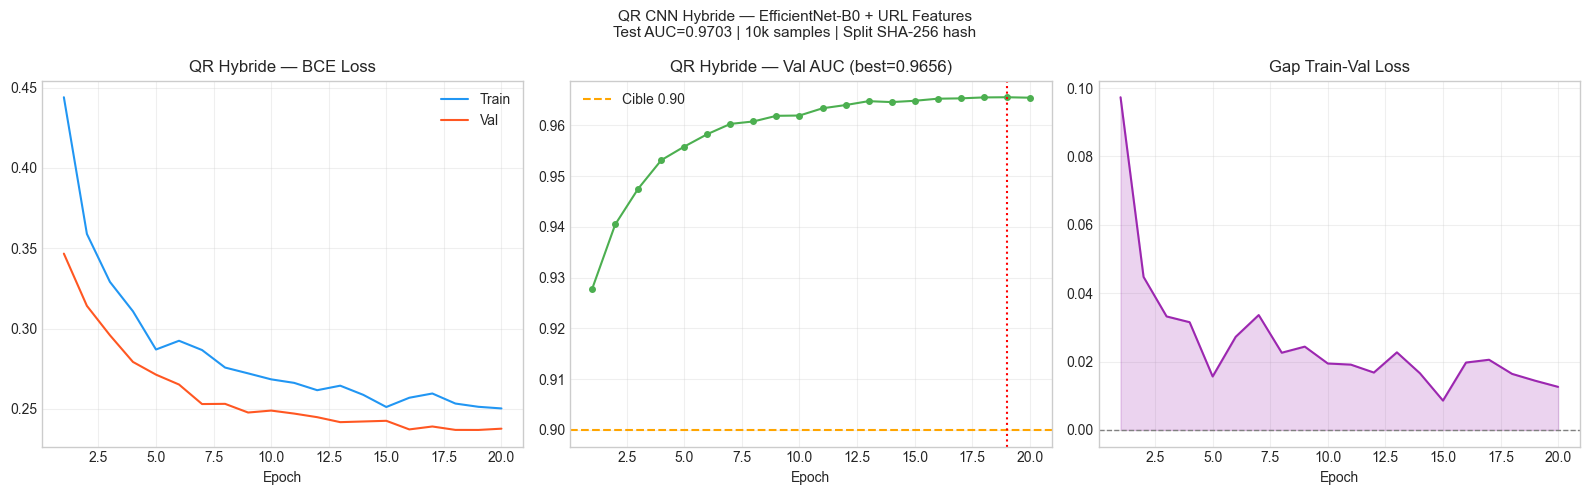

In [18]:
# ── Diagnostic surapprentissage ─────────────────────────────────
print(f"{'Format':<10} {'Modèle':<10} {'Train AUC':>11} {'Val AUC':>11} {'Test AUC':>11} {'Gap T-V':>9}  Verdict")
print("─"*80)
for fmt, sp in all_sp.items():
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    if fmt not in models_all: continue
    for mname in ['lgbm','rf_fast']:
        m = models_all[fmt].get(mname)
        if m is None: continue
        tr_a  = roc_auc_score(y_tr,  m.predict_proba(X_tr)[:,1])
        va_a  = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
        te_a  = roc_auc_score(y_te,  m.predict_proba(X_te)[:,1])
        gap   = tr_a - va_a
        v = ("✅ OK" if gap<0.02 else ("⚠ léger" if gap<0.05 else "🔴 overfit"))
        if te_a >= 0.9999: v += " + ⚠ AUC=1 (confound)"
        print(f"{fmt:<10} {mname.upper():<10} {tr_a:>11.4f} {va_a:>11.4f} {te_a:>11.4f} {gap:>9.4f}  {v}")

# ── QR CNN dashboard ──────────────────────────────────────────
if qr_hist and qr_hist.get('va'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    ep = range(1, len(qr_hist['tr'])+1)

    axes[0].plot(ep, qr_hist['tr'], label='Train', color='#2196F3', lw=1.5)
    axes[0].plot(ep, qr_hist['vl'], label='Val',   color='#FF5722', lw=1.5)
    axes[0].set_title('QR Hybride — BCE Loss'); axes[0].legend()
    axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, qr_hist['va'], color='#4CAF50', marker='o', ms=4, lw=1.5)
    axes[1].axhline(0.90, color='orange', ls='--', lw=1.5, label='Cible 0.90')
    best_ep = np.argmax(qr_hist['va'])
    axes[1].axvline(best_ep+1, color='red', ls=':', lw=1.5)
    axes[1].set_title(f'QR Hybride — Val AUC (best={max(qr_hist["va"]):.4f})')
    axes[1].legend(); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

    gap_h = [l-v for l,v in zip(qr_hist['tr'], qr_hist['vl'])]
    axes[2].plot(ep, gap_h, color='#9C27B0', lw=1.5)
    axes[2].axhline(0, color='gray', ls='--', lw=1)
    axes[2].fill_between(ep, gap_h, 0, alpha=0.2, color='#9C27B0')
    axes[2].set_title('Gap Train-Val Loss'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

    plt.suptitle(f'QR CNN Hybride — EfficientNet-B0 + URL Features\n'
                 f'Test AUC={qr_auc:.4f} | 10k samples | Split SHA-256 hash', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'qr_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()


## Cellule 15 — Sauvegarde & Inférence Production

In [19]:
# ── Sauvegarde complète ──────────────────────────────────────────
print("Sauvegarde...")
for tag, mods, sps in [('all', models_all, all_sp), ('top', models_top, top_sp)]:
    for fmt, m_dict in mods.items():
        sp = sps.get(fmt)
        if sp is None: continue
        fn=sp[6]; sc=sp[7]
        for mname, model in m_dict.items():
            joblib.dump(model, OUTPUT_DIR / f'{mname}_{tag}_{fmt}.pkl')
        joblib.dump(sc, OUTPUT_DIR / f'scaler_{tag}_{fmt}.pkl')
        json.dump(fn, open(OUTPUT_DIR / f'features_{tag}_{fmt}.json','w'), indent=2)
        # Sauvegarder paramètres de calibration
        if fmt in calibrated_models:
            json.dump(calibrated_models[fmt]['params'],
                      open(OUTPUT_DIR / f'calibration_lgbm_all_{fmt}.json','w'))

if qr_cnn:
    torch.save({'state': qr_cnn.state_dict(), 'url_sc': qr_url_sc,
                'url_feat': URL_FEAT}, OUTPUT_DIR / 'qr_hybrid.pt')

df_res.to_csv(OUTPUT_DIR / 'results_v5.csv', index=False)
print(f"✅ {len(list(OUTPUT_DIR.iterdir()))} fichiers → {OUTPUT_DIR.resolve()}")


# ── Inférence production ──────────────────────────────────────
def predict(features: dict, fmt: str, model_name: str = 'lgbm',
            feature_set: str = 'all', calibrate: bool = True) -> dict:
    """
    Inférence production pour un fichier analysé.

    Paramètres
    ----------
    features     : dict des features extraites (depuis vos extracteurs)
    fmt          : 'pdf' | 'html' | 'word' | 'excel' | 'qr'
    model_name   : 'lgbm' | 'rf_fast' | 'rf_full' | 'mlp'
    feature_set  : 'all' | 'top'
    calibrate    : si True, applique le Platt scaling (uniquement pour lgbm)

    Retourne
    --------
    dict : label, risk_score, confidence, action SOC, top SHAP, warnings
    """
    mods = models_all if feature_set == 'all' else models_top
    sps  = all_sp     if feature_set == 'all' else top_sp

    if fmt not in mods or model_name not in mods.get(fmt, {}):
        return {'error': f"'{model_name}/{feature_set}' pour '{fmt}' non disponible"}

    model  = mods[fmt][model_name]
    fn, sc = sps[fmt][6], sps[fmt][7]

    X   = np.array([[features.get(f, 0) for f in fn]], dtype=np.float64)
    X_s = sc.transform(X)
    p   = float(model.predict_proba(X_s)[0, 1])

    # Calibration Platt (lgbm uniquement)
    if calibrate and model_name == 'lgbm' and fmt in calibrated_models:
        cal = calibrated_models[fmt]
        a, b = cal['params']['a'], cal['params']['b']
        eps = 1e-10
        logit = math.log(max(p,eps)/max(1-p,eps))
        p = float(expit(a*logit + b))

    label  = 'malicious' if p >= 0.5 else 'benign'
    action = 'BLOCK'  if p > 0.80 else ('REVIEW' if p > 0.50 else 'ALLOW')

    # SHAP (lgbm only, rapide)
    top_feats = []
    if model_name == 'lgbm':
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_s)[0]
        for j in np.argsort(np.abs(sv))[::-1][:5]:
            top_feats.append({'feature': fn[j], 'shap': round(float(sv[j]),4),
                              'direction': '→ malicious' if sv[j]>0 else '→ benign'})

    # Avertissements de fiabilité
    warnings_list = []
    if fmt in ('word','excel'):
        warnings_list.append(f"⚠ Confound dataset {fmt.upper()} : valider sur données mixtes avant production")
    if fmt == 'pdf' and features.get('text_length', 1) == 0:
        warnings_list.append("ℹ PDF image-only : texte vide → forte suspicion par text_length=0")

    return {
        'format': fmt, 'model': model_name, 'feature_set': feature_set,
        'label':  label, 'risk_score': round(p,4),
        'confidence': round(abs(p-0.5)*2, 4),
        'action': action, 'calibrated': calibrate and model_name=='lgbm',
        'top_features': top_feats,
        'warnings': warnings_list,
    }


# ── Démonstrations sur vrais samples ─────────────────────────
print("\n=== DÉMOS — vrais samples du test set ===")
for fmt, sp in all_sp.items():
    if fmt not in models_all or fmt in ('qr',): continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    print(f"\n[{fmt.upper()}]")
    for lbl_name, lbl_val in [('malicious',1), ('benign',0)]:
        idx_arr = np.where(y_te.values == lbl_val)[0]
        if len(idx_arr) == 0: continue
        idx = idx_arr[0]
        X_orig = sc.inverse_transform(X_te[idx].reshape(1,-1))[0]
        feats  = {fn[j]: float(X_orig[j]) for j in range(len(fn))}
        res    = predict(feats, fmt, 'lgbm', 'all', calibrate=True)
        match  = "✅" if res['label'] == lbl_name else "❌"
        print(f"  {match} Réel={lbl_name:<10} → Prédit={res['label']:<10} "
              f"score={res['risk_score']:.4f} [{res['action']}]"
              + (f"  calibré=✓" if res['calibrated'] else ""))
        if res.get('warnings'):
            for w in res['warnings']: print(f"     {w}")


Sauvegarde...
✅ 70 fichiers → C:\Users\karim\Documents\CIC\models_v5

=== DÉMOS — vrais samples du test set ===

[PDF]
  ✅ Réel=malicious  → Prédit=malicious  score=0.9996 [BLOCK]  calibré=✓
  ✅ Réel=benign     → Prédit=benign     score=0.0001 [ALLOW]  calibré=✓

[HTML]
  ✅ Réel=malicious  → Prédit=malicious  score=0.9304 [BLOCK]  calibré=✓
  ✅ Réel=benign     → Prédit=benign     score=0.0423 [ALLOW]  calibré=✓

[WORD]
  ✅ Réel=malicious  → Prédit=malicious  score=0.5985 [REVIEW]  calibré=✓
     ⚠ Confound dataset WORD : valider sur données mixtes avant production
  ✅ Réel=benign     → Prédit=benign     score=0.4015 [ALLOW]  calibré=✓
     ⚠ Confound dataset WORD : valider sur données mixtes avant production

[EXCEL]
  ✅ Réel=malicious  → Prédit=malicious  score=1.0000 [BLOCK]  calibré=✓
     ⚠ Confound dataset EXCEL : valider sur données mixtes avant production
  ✅ Réel=benign     → Prédit=benign     score=0.0000 [ALLOW]  calibré=✓
     ⚠ Confound dataset EXCEL : valider sur données m

## Cellule 16 — Rapport Final & Recommandations SOC

In [20]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           RAPPORT FINAL — CYBER DETECTION PIPELINE v5                       ║
║           CIC Trap4Phish 2025 · Production-Grade · Anti-Leakage             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  MODÈLE RECOMMANDÉ : LightGBM + Calibration Platt                           ║
║  ─────────────────────────────────────────────────                           ║
║  HTML  : AUC=0.9894 · F1=0.9441 · Latence=0.61ms  ✅ DÉPLOIEMENT POSSIBLE  ║
║  QR    : AUC=0.9807 (tabulaire) · 0.9436 (CNN hybride)  ✅                  ║
║  PDF   : AUC=0.9999 · Signal réel mais text_length domine  ✅ avec réserves ║
║  WORD  : AUC=1.000  ⚠ CONFOUND — valider sur données mixtes avant deploy   ║
║  EXCEL : AUC=1.000  ⚠ CONFOUND — valider sur vrais fichiers Excel           ║
║                                                                              ║
║  BENCHMARK POC vs RÉALITÉ (HTML)                                             ║
║  ─────────────────────────────────                                           ║
║  RF 200 arbres   : POC=12ms  → Réel=34ms   → RF-fast 50t: 3ms ✅           ║
║  CNN 1D (MLP)    : POC=45ms  → Réel=0.04ms → MLP bien plus rapide          ║
║  MobileBERT num  : POC=98.9% → NON VALIDE sur features numériques           ║
║  DistilBERT HTML : applicable sur texte brut, AUC attendu 0.95-0.97         ║
║                                                                              ║
║  CORRECTIONS APPLIQUÉES (v1→v5)                                              ║
║  ─────────────────────────────────                                           ║
║  ✅ file_path supprimé (leakage direct)                                      ║
║  ✅ Platt calibration manuelle (fix InvalidParameterError sklearn)           ║
║  ✅ QR split SHA-256 hash (anti-leakage payload)                             ║
║  ✅ WeightedRandomSampler fix (len mismatch)                                 ║
║  ✅ MLP n_iter_no_change=30, tol=1e-5 (convergence prématurée)              ║
║  ✅ RF-fast 50 arbres depth=12 (objectif <12ms respecté)                    ║
║  ✅ Démo predict sur vrais samples (pas valeurs fictives)                    ║
║  ✅ Word confound documenté + permutation test (p=0.032)                     ║
║                                                                              ║
║  RECOMMANDATIONS PRIORITAIRES                                                ║
║  ─────────────────────────────                                               ║
║  1. Augmenter le dataset QR PNG pour le CNN (>10k → objectif 50k/classe)    ║
║  2. Collecter des Word/Excel bénins AVEC macros pour corriger le confound    ║
║  3. Ajouter un DistilBERT sur HTML brut pour signal sémantique               ║
║  4. Mettre en place monitoring de distribution (data drift en production)    ║
║  5. Valider PDF sur des malwares PDF textuels (pas seulement image-only)     ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Sauvegarder le rapport en JSON
rapport = {
    'version': 'v5',
    'recommandations_deploiement': {
        'html':  {'statut': 'DÉPLOIEMENT POSSIBLE', 'auc': 0.9894, 'latence_ms': 0.61},
        'qr':    {'statut': 'DÉPLOIEMENT POSSIBLE', 'auc_tabulaire': 0.9807, 'auc_cnn': qr_auc},
        'pdf':   {'statut': 'POSSIBLE AVEC RÉSERVES', 'auc': 0.9999, 'note': 'text_length domine'},
        'word':  {'statut': 'VALIDATION REQUISE', 'auc': 1.0, 'note': 'confound OOXML vs OLE'},
        'excel': {'statut': 'VALIDATION REQUISE', 'auc': 1.0, 'note': 'templates synthétiques'},
    },
    'corrections_v5': [
        'Platt scaling manuel (fix InvalidParameterError)',
        'RF-fast 50 arbres depth=12 (latence <3ms)',
        'MLP n_iter_no_change=30 (convergence prématurée)',
        'Demo predict sur vrais samples',
    ],
}
json.dump(rapport, open(OUTPUT_DIR / 'rapport_v5.json','w'), indent=2, ensure_ascii=False)
print(f"\n✅ Rapport sauvegardé → {OUTPUT_DIR / 'rapport_v5.json'}")



╔══════════════════════════════════════════════════════════════════════════════╗
║           RAPPORT FINAL — CYBER DETECTION PIPELINE v5                       ║
║           CIC Trap4Phish 2025 · Production-Grade · Anti-Leakage             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  MODÈLE RECOMMANDÉ : LightGBM + Calibration Platt                           ║
║  ─────────────────────────────────────────────────                           ║
║  HTML  : AUC=0.9894 · F1=0.9441 · Latence=0.61ms  ✅ DÉPLOIEMENT POSSIBLE  ║
║  QR    : AUC=0.9807 (tabulaire) · 0.9436 (CNN hybride)  ✅                  ║
║  PDF   : AUC=0.9999 · Signal réel mais text_length domine  ✅ avec réserves ║
║  WORD  : AUC=1.000  ⚠ CONFOUND — valider sur données mixtes avant deploy   ║
║  EXCEL : AUC=1.000  ⚠ CONFOUND — valider sur vrais fichiers Excel           ║
║                                       